## Imports

In [36]:
import os
import re
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.exceptions import ConvergenceWarning
from sklearn.feature_selection import mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LassoCV
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm


from typing import Dict, List, Optional, Tuple
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_regression

import gc

from sklearn.feature_selection import RFECV

from sklearn.model_selection import cross_val_score
from functools import lru_cache


# At the very beginning of the code, before calling model_function
warnings.filterwarnings("ignore", category=ConvergenceWarning)

## Downloading datasets

In [2]:
model_df = pd.read_pickle("pkls/model_df_full")
factors = pd.read_pickle("pkls/factors_full")

## Feature engineering

In [3]:
def get_feature_metadata(feat_name):
    """
    Returns (Description, Group) using a two-level hierarchy: {category}.{source}.
    Categories: memory, momentum, relative, channels, volatility, trend, 
                cross_asset, tails, fractal, seasonal, spread, stationarity, logistics.
    Sources: price, macro, commodity, currency, freight, volume, supply_demand, or combined (e.g. price_freight).
    """
        # Add these inside get_feature_metadata(feat_name):
    if '_vola_vol_prod_' in feat_name:
        return "Volatility and volume synergy interaction", "volatility.combined"
    if 'mom_spread_' in feat_name:
        return "Cross-asset momentum divergence spread", "momentum.cross_asset"
    if '_breakout_' in feat_name:
        return "Historical channel high/low breakout flag", "tails.price"
    if '_cum_flow_' in feat_name:
        return "Cumulative rolling position flow accumulation", "volume.positions"
    if '_log_ret_' in feat_name and any(f"{i}w" in feat_name for i in [1, 2, 4, 12, 52]):
        return "Multi-period logarithmic return trend", f"stationarity.{_extract_source(feat_name)}"
    
    def _extract_source(name):
        # Maps short prefixes to semantic source names
        prefix_map = {'pr': 'price', 'e': 'indexes', 'c': 'commodity', 
                      '$': 'currency', 'b': 'freight', 'v': 'volume', 
                      'sd': 'supply_demand', "fp": "futures_positions"}
        for p, src in prefix_map.items():
            if name.startswith(p + '_') or name.startswith(p):
                return src
        return 'technical'

    # 1. Memory / Lags
    if '_lag_' in feat_name:
        window = feat_name.split('_lag_')[-1]
        return f"Lag {window} periods", f"memory.{_extract_source(feat_name)}"
    
    # 2. Momentum
    if '_diff_1_smooth' in feat_name:
        return "Smoothed momentum (4w MA)", f"momentum.{_extract_source(feat_name)}"
    if '_diff_' in feat_name:
        window = feat_name.split('_diff_')[-1]
        return f"Difference over {window} periods", f"momentum.{_extract_source(feat_name)}"
    if '_accel' in feat_name:
        return "Momentum acceleration (2nd diff)", f"momentum.{_extract_source(feat_name)}"
    
    # 3. Relative Strength / Ratios
    if '_div_' in feat_name:
        parts = feat_name.split('_div_')
        src_a = _extract_source(parts[0])
        src_b = _extract_source(parts[1]) if len(parts) > 1 else 'other'
        source = f"{src_a}_{src_b}" if src_a != src_b else src_a
        return "Relative strength ratio", f"relative.{source}"
    
    # 4. Channels & Levels
    if '_rel_pos_' in feat_name:
        window = feat_name.split('_rel_pos_')[-1]
        return f"Relative position in {window}w range [0-1]", f"channels.{_extract_source(feat_name)}"
    if '_dist_sma_' in feat_name:
        window = feat_name.split('_dist_sma_')[-1]
        return f"Distance to {window}w SMA", f"channels.{_extract_source(feat_name)}"
    if '_sma_pct_' in feat_name:
        window = feat_name.split('_sma_pct_')[-1]
        return f"{window}w SMA slope (% change)", f"channels.{_extract_source(feat_name)}"
    
    # 5. Volatility
    if '_spread_' in feat_name:
        window = feat_name.split('_spread_')[-1]
        return f"Range spread vs SMA ({window}w)", f"volatility.{_extract_source(feat_name)}"
    if '_zscore_' in feat_name:
        window = feat_name.split('_zscore_')[-1]
        return f"Z-score ({window}w)", f"volatility.{_extract_source(feat_name)}"
    if '_ann_vol_' in feat_name:
        window = feat_name.split('_ann_vol_')[-1]
        return f"Annualized volatility ({window}w)", f"volatility.{_extract_source(feat_name)}"
    if '_vol_pct_' in feat_name:
        window = feat_name.split('_vol_pct_')[-1]
        return f"Volatility % change ({window}w)", f"volatility.{_extract_source(feat_name)}"
    
    # 6. Trend Health
    if '_up_weeks_' in feat_name:
        return "Count of up weeks (12w)", "trend.price"
    if '_er_' in feat_name:
        return "Efficiency ratio (trend purity)", "trend.price"
    
    # 7. Cross-Asset Correlations
    if '_corr_' in feat_name:
        parts = feat_name.split('_corr_')
        src_a = _extract_source(parts[0])
        src_b = _extract_source(parts[1].split('_')[0]) if len(parts) > 1 else 'other'
        source = f"{src_a}_{src_b}" if src_a != src_b else src_a
        return "Rolling correlation (13w)", f"cross_asset.{source}"
    
    # 8. Tails & Extremes
    if '_weeks_since_max' in feat_name:
        return "Weeks since rolling high (52w)", f"tails.{_extract_source(feat_name)}"
    if '_is_outlier' in feat_name:
        return "Outlier flag (|Z| > 2.5)", f"tails.{_extract_source(feat_name)}"
    
    # 9. Fractality
    if '_fractal_dim' in feat_name:
        return "Fractal dimension / Hurst proxy", "fractal.price"
    
    # 10. Seasonality
    if '_exp_mean_month' in feat_name:
        return "Expanding seasonal mean by month", "seasonal.price"
    
    # 11. Spread Dynamics
    if '_conv' in feat_name and '_vs_' in feat_name:
        parts = feat_name.split('_vs_')
        src_a = _extract_source(parts[0])
        src_b = _extract_source(parts[1].split('_')[0]) if len(parts) > 1 else 'other'
        source = f"{src_a}_{src_b}" if src_a != src_b else src_a
        return "Convergence rate (4w price diff)", f"spread.{source}"
    
    # 12. Logistics & Delta Features
    if 'delta_log_ret_' in feat_name:
        return "Log return spread (delta)", "logistics.freight_price"
    if 'logistics_cost_pressure_' in feat_name:
        return "Logistics cost pressure (freight/price)", "logistics.freight_price"
    
    # 13. Stationarity
    if '_log_ret' in feat_name:
        return "Logarithmic return", f"stationarity.{_extract_source(feat_name)}"
    
    # Fallback
    return "Derived feature", f"technical.{_extract_source(feat_name)}"

In [4]:
def generate_all_features(df_input, original_factors=None):
    """Generates technical, macro, cross-asset, and synergy features.

    Protects against data leakage via chronological shifting, optimizes
    memory usage to prevent fragmentation, and seamlessly integrates
    multi-period log returns and asset interaction vectors.
    """
    import pandas as pd
    import numpy as np
    
    # 0. Chronological sorting and basic preparation
    df = df_input.copy()
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

    cols = df.columns
    pr_cols = [c for c in cols if c.startswith("pr")]
    e_cols = [c for c in cols if c.startswith("e")]
    c_cols = [c for c in cols if c.startswith("c")]
    b_cols = [c for c in cols if c.startswith("b")]
    v_cols = [c for c in cols if c.startswith("v")]
    curr_cols = [c for c in cols if c.startswith("$")]
    fp_cols = [c for c in cols if c.startswith("fp")]
    sd_cols = [c for c in cols if c.startswith("sd")]

    # Analytical rolling horizons
    windows_lag = (1, 2, 3, 4, 12, 52)
    windows_diff = (1, 4, 52)
    windows_extended = (12, 52, 104)

    # Sanitize price-like metrics to protect log conversions
    price_likes = pr_cols + e_cols + c_cols + curr_cols
    for col in price_likes:
        if col in df.columns:
            df[col] = df[col].apply(lambda x: x if x > 0 else np.nan).ffill()

    # Separate feature groups
    univariate_cols = (
        e_cols + c_cols + b_cols + v_cols + curr_cols + fp_cols + sd_cols
    )
    cross_asset_base_cols = pr_cols
    price_factors = e_cols + c_cols + curr_cols + b_cols

    # High-performance accumulator map
    new_features = {}

    def in_all(col_list):
        all_features = (
            pr_cols + e_cols + c_cols + b_cols + v_cols + curr_cols + sd_cols
        )
        return [c for c in col_list if c in all_features]

    # =====================================================================
    # 🌟 TARGET CONFIGURATION (Next week's log return forecasting)
    # =====================================================================
    df["pr_next"] = df["pr"].shift(-1)
    new_features["target_log_return"] = np.log(df["pr_next"] / df["pr"])

    # 🧠 Memory (Lags)
    for col in univariate_cols:
        for lag in windows_lag:
            new_features[f"{col}_lag_{lag}"] = df[col].shift(lag)

    # 🚀 Momentum
    for col in univariate_cols:
        diff_1 = df[col].diff(1)
        new_features[f"{col}_diff_1"] = diff_1
        for diff in windows_diff:
            new_features[f"{col}_diff_{diff}"] = df[col].diff(diff)
        new_features[f"{col}_accel"] = diff_1 - diff_1.shift(1)
        new_features[f"{col}_diff_1_smooth"] = diff_1.rolling(window=4).mean()

    # ⚖️ Relative Strength (Level Ratios)
    for pr in in_all(cross_asset_base_cols):
        for e in in_all(e_cols):
            new_features[f"{pr}_div_{e}"] = df[pr] / df[e]
        for c in in_all(c_cols):
            new_features[f"{pr}_div_{c}"] = df[pr] / df[c]
        for b in in_all(b_cols):
            new_features[f"{pr}_div_{b}"] = df[pr] / df[b]
        for cur in in_all(curr_cols):
            new_features[f"{pr}_div_{cur}"] = df[pr] / df[cur]

    # 📊 Channels & Levels
    for col in univariate_cols:
        for window in windows_extended:
            r_min = df[col].rolling(window).min()
            r_max = df[col].rolling(window).max()
            r_mean = df[col].rolling(window).mean()
            new_features[f"{col}_rel_pos_{window}"] = (
                (df[col] - r_min) / (r_max - r_min + 1e-9)
            )
            new_features[f"{col}_dist_sma_{window}"] = df[col] - r_mean
            new_features[f"{col}_sma_pct_{window}"] = (
                r_mean.pct_change(periods=1)
            )

    # 📉 Volatility Structure
    for col in univariate_cols:
        for window in windows_extended:
            r_min = df[col].rolling(window).min()
            r_max = df[col].rolling(window).max()
            r_mean = df[col].rolling(window).mean()
            r_std = df[col].rolling(window).std()
            new_features[f"{col}_spread_{window}"] = (
                (r_max - r_min) / (r_mean + 1e-9)
            )
            new_features[f"{col}_zscore_{window}"] = (
                (df[col] - r_mean) / (r_std + 1e-9)
            )
            new_features[f"{col}_ann_vol_{window}"] = r_std * np.sqrt(52)
            new_features[f"{col}_vol_pct_{window}"] = (
                r_std.pct_change(periods=1)
            )

    # 🩺 Trend Purity
    for col in in_all(pr_cols):
        is_up = (df[col].diff(1) > 0).astype(int)
        new_features[f"{col}_up_weeks_12"] = is_up.rolling(window=12).sum()
        total_move = abs(df[col] - df[col].shift(12))
        sum_abs_moves = df[col].diff(1).abs().rolling(window=12).sum()
        new_features[f"{col}_er_12"] = total_move / (sum_abs_moves + 1e-9)

    # 🔗 Rolling Cross-Asset Correlations
    for pr in in_all(cross_asset_base_cols):
        for c in in_all(c_cols):
            new_features[f"{pr}_corr_{c}_13"] = (
                df[pr].rolling(window=13).corr(df[c])
            )
        for cur in in_all(curr_cols):
            new_features[f"{pr}_corr_{cur}_13"] = (
                df[pr].rolling(window=13).corr(df[cur])
            )

    # 💥 Distribution Tails & Extremes (Vectorized Optimization)
    for col in in_all(pr_cols) + in_all(curr_cols) + in_all(e_cols):
        rolling_max_idx = (
            df[col]
            .rolling(window=52)
            .apply(lambda x: np.argmax(x), raw=True)
            .astype(float)
        )
        new_features[f"{col}_weeks_since_max"] = 52 - 1 - rolling_max_idx

        r_mean = df[col].rolling(window=52).mean()
        r_std = df[col].rolling(window=52).std()
        z = (df[col] - r_mean) / (r_std + 1e-9)
        new_features[f"{col}_is_outlier"] = (z.abs() > 2.5).astype(int)

    # 🌀 Fractality
    for col in in_all(pr_cols):
        high_low = (
            df[col].rolling(window=12).max() - df[col].rolling(window=12).min()
        )
        sum_daily_range = (
            (df[col] - df[col].shift(1)).abs().rolling(window=12).sum()
        )
        new_features[f"{col}_fractal_dim"] = high_low / (
            sum_daily_range + 1e-9
        )

    # 📆 Expanding Seasonal Means
    df["Month"] = df["Date"].dt.month
    for col in in_all(pr_cols):
        new_features[f"{col}_exp_mean_month"] = (
            df.groupby("Month")[col]
            .transform(lambda x: x.expanding().mean().shift(1))
        )

    # 🎚️ Spread Dynamics
    for pr in in_all(cross_asset_base_cols):
        for c in in_all(c_cols):
            new_features[f"{pr}_vs_{c}_conv"] = (
                df[pr].pct_change(4) - df[c].pct_change(4)
            )

    # =====================================================================
    # 🌟 MULTI-PERIOD LOG RETURNS FOR MARKET PRICE FACTORS
    # =====================================================================
    for col in price_factors:
        if col in df.columns:
            # Wrap in context manager to suppress log zero/negative runtime warnings
            with np.errstate(invalid="ignore"):
                new_features[f"{col}_log_ret_1w"] = np.log(
                    df[col] / df[col].shift(1)
                )
                for horizon in (2, 4, 12, 52):
                    new_features[f"{col}_log_ret_{horizon}w"] = np.log(
                        df[col] / df[col].shift(horizon)
                    )

    # 📏 Stationary Log Returns (Current Week Basis for other variables)
    for col in univariate_cols:
        if col in fp_cols and df[col].min() < 0:
            continue
        if col in price_factors:
            continue
        with np.errstate(invalid="ignore"):
            new_features[f"{col}_log_ret"] = np.log(df[col] / df[col].shift(1))

    # 🚢 Logistics cost pressures
    for b in in_all(b_cols):
        for pr in in_all(cross_asset_base_cols):
            with np.errstate(invalid="ignore"):
                pr_log = np.log(df[pr] / df[pr].shift(1))
                b_log = np.log(df[b] / df[b].shift(1))
            new_features[f"delta_log_ret_{b}_vs_{pr}"] = b_log - pr_log
            new_features[f"logistics_cost_pressure_{b}_{pr}"] = df[b] / df[pr]

    # =====================================================================
    # 🌟 ADVANCED FEATURE SYNERGY EXTENSIONS
    # =====================================================================

    # A. Volatility & Volume Interaction Mapping
    for col_fp in fp_cols:
        if col_fp in df.columns:
            for pr in in_all(cross_asset_base_cols):
                pr_std = df[pr].rolling(window=12).std()
                pr_mean = df[pr].rolling(window=12).mean()
                pr_z = (df[pr] - pr_mean) / (pr_std + 1e-9)

                fp_std = df[col_fp].rolling(window=12).std()
                fp_mean = df[col_fp].rolling(window=12).mean()
                fp_z = (df[col_fp] - fp_mean) / (fp_std + 1e-9)

                new_features[f"{pr}_vola_vol_prod_{col_fp}_12"] = pr_z * fp_z

    # B. Momentum Spreads (Relative Tracking Asset Vector Speeds)
    for pr in in_all(cross_asset_base_cols):
        with np.errstate(invalid="ignore"):
            pr_log = np.log(df[pr] / df[pr].shift(1))
        for c in in_all(c_cols):
            with np.errstate(invalid="ignore"):
                c_log = np.log(df[c] / df[c].shift(1))
            new_features[f"mom_spread_{pr}_vs_{c}"] = pr_log - c_log
        for cur in in_all(curr_cols):
            with np.errstate(invalid="ignore"):
                cur_log = np.log(df[cur] / df[cur].shift(1))
            new_features[f"mom_spread_{pr}_vs_{cur}"] = pr_log - cur_log

    # C. Historical Regime Channel Breakouts
    for col in in_all(pr_cols) + in_all(c_cols) + in_all(curr_cols):
        for window in windows_extended:
            rolling_max = df[col].shift(1).rolling(window=window).max()
            rolling_min = df[col].shift(1).rolling(window=window).min()
            new_features[f"{col}_breakout_high_{window}"] = ((df[col] >= rolling_max).astype(int))
            new_features[f"{col}_breakout_low_{window}"] = ((df[col] <= rolling_min).astype(int))

    # D. Cumulative Volume & Flow Integral Accumulation
    for col_fp in fp_cols:
        if col_fp in df.columns:
            if df[col_fp].abs().max() <= 100:
                continue
            fp_pct = df[col_fp].pct_change()
            for window in (4, 12):
                new_features[f"{col_fp}_cum_flow_{window}"] = (fp_pct.rolling(window=window).sum())

    # --- METADATA REGISTRY UPDATES ---
    def get_feature_metadata(feat):
        """Helper function to get feature metadata"""
        # Simple metadata generation
        if "log_ret" in feat:
            return "Logarithmic return", "Returns"
        elif "lag" in feat:
            return "Lagged value", "Lags"
        elif "diff" in feat:
            return "Difference", "Momentum"
        elif "corr" in feat:
            return "Correlation", "Cross-Asset"
        elif "breakout" in feat:
            return "Channel breakout", "Technical"
        else:
            return "Technical indicator", "Technical"
    
    new_meta = []
    for feat in new_features.keys():
        desc, group = get_feature_metadata(feat)
        new_meta.append({"Factor": feat, "Description": desc, "Group": group})
    
    new_factors_df = pd.DataFrame(new_meta, columns=["Factor", "Description", "Group"])
    
    if original_factors is not None:
        updated_factors = pd.concat([original_factors, new_factors_df], ignore_index=True)
    else:
        updated_factors = new_factors_df
    
    updated_factors["Group"] = (updated_factors["Group"].str.rsplit(".", n=1).str[-1])
    
    # Atomic frame compilation avoiding fragmentation
    df_features = pd.DataFrame(new_features, index=df.index)
    df = pd.concat([df, df_features], axis=1)
    df = df.replace([np.inf, -np.inf], np.nan)
    df.drop(columns=["Month"], errors="ignore", inplace=True)
    
    return df, updated_factors

In [5]:
factors

,Factor,Description,Group
0,e1,EEM_ETF_Stock_Price_History.csv,indexes
1,e2,EuroNext_100_Historical_Data.csv,indexes
2,e3,MSCI_EFM_Africa_Ex_South_Africa_NR_USD_Histori...,indexes
3,e4,MSCI_EM_Asia_Net_USD_Historical_Data.csv,indexes
4,e5,S&P_500_Futures_Historical_Data.csv,indexes
...,...,...,...
88,fp25,Prod_Merc_Total,futures_positions
89,fp26,Swap_Total,futures_positions
90,fp27,M_Money_vs_Prod_Merc,futures_positions
91,fp28,M_Money_vs_Swap,futures_positions


In [6]:
# 1. Execute unified feature generation pipeline
# Note: Ensure variable 'factors' matches your global metadata dataframe name
model_df, factors = generate_all_features(model_df, original_factors=factors)


# 2. Handle missing data progressively to preserve full history depth
df_filled = model_df.copy()

# Step A: Fill all momentum/differential/return columns with zeros
change_suffixes = [
    "_log_ret",
    "_pct_chg",
    "_diff_1",
    "_diff_4",
    "_diff_52",
    "_mom_chg",
    "_yoy_chg",
    "_accel",
]
for col in df_filled.columns:
    if any(suffix in col for suffix in change_suffixes):
        df_filled[col] = df_filled[col].fillna(0)

# Step B: Backfill technical rolling levels with their first valid value
df_filled = df_filled.bfill()

# Step C: Replace remaining mathematical infinity anomalies with zeros
df_filled.replace([np.inf, -np.inf], np.nan, inplace=True)
df_filled = df_filled.fillna(0)

# Step D: Drop exclusively the last row since future pr_next is unknown
df_final_model = df_filled.dropna(subset=["target_log_return"])

print("=== DATASET COMPILATION METRICS ===")
print(f"Final feature space design matrix shape: {df_final_model.shape}")
print(f"Preserved historical data depth: {len(df_final_model)} rows.")
print("Data matrices are fully prepared for predictive ML algorithms.")

=== DATASET COMPILATION METRICS ===
Final feature space design matrix shape: (704, 3243)
Preserved historical data depth: 704 rows.
Data matrices are fully prepared for predictive ML algorithms.


## Feature selection

### Banchmark data creating/collecting

In [7]:
start_period = 264
learning_step = 20
end_period = model_df.shape[0]

training_data_depths =[2, 7, 'all']

### Main function & dataset

In [8]:
empty_results_df = model_df[['Date', 'pr', 'pr_next']][start_period:]

In [9]:
# def model_function(model_df, years="All", start_period=104, end_period=None,
#                    learning_step=40, marker="lasso", n_jobs=-1, 
#                    fs_method=None, param=None):
#     """Trains a rolling-window Lasso model on log returns.

#     Predicts next week's log returns and inverse-transforms them 
#     back into absolute price levels before returning the results.
#     """
#     predictions_inner = []
#     coef_history = []
#     alpha_history = []
#     metrics_history = []

#     # Features extraction following strict original order
#     exclude_cols = {"pr", "pr_next", "Date", "YearWeek", "target_log_return"}
#     features = [col for col in model_df.columns if col not in exclude_cols]

#     if end_period is None:
#         end_period = len(model_df)

#     tscv = TimeSeriesSplit(n_splits=3)

#     for period in tqdm(range(start_period, end_period, learning_step), 
#                       desc=f"Processing {marker}"):
#         current_step = min(learning_step, len(model_df) - period)
#         if current_step <= 0:
#             break

#         # Define temporal slices for training data
#         if isinstance(years, str) or years * 52 > period:
#             X_train = model_df[features].iloc[:period].copy()
#             y_train = model_df["target_log_return"].iloc[:period].copy()
#             prices_train = model_df["pr"].iloc[:period].values
#             real_prices_train_next = model_df["pr_next"].iloc[:period].values
#         else:
#             start_idx = period - years * 52
#             X_train = model_df[features].iloc[start_idx:period].copy()
#             y_train = model_df["target_log_return"].iloc[start_idx:period].copy()
#             prices_train = model_df["pr"].iloc[start_idx:period].values
#             real_prices_train_next = model_df["pr_next"].iloc[start_idx:period].values

#         # Define temporal slices for test data
#         X_test = model_df[features].iloc[period : period + current_step].copy()
#         prices_test = model_df["pr"].iloc[period : period + current_step].values
#         real_prices_test_next = (
#             model_df["pr_next"].iloc[period : period + current_step].values
#         )

#         # Feature selection engine integration
#         current_active_features = features.copy()
#         if fs_method is not None:
#             selected = fs_method(X_train, y_train, param)
#             current_active_features = [c for c in features if c in selected]
#             X_train = X_train[current_active_features]
#             X_test = X_test[current_active_features]

#         if len(current_active_features) == 0:
#             continue

#         # Scale data out-of-CV to prevent data leakage
#         scaler = StandardScaler()
#         X_train_scaled = scaler.fit_transform(X_train)
#         X_test_scaled = scaler.transform(X_test)

#         # Lasso cross-validation set configuration for log returns scales
#         lasso_final = LassoCV(
#             eps=1e-3,           # Lifts the floor to drop weak, noisy coefficients
#             alphas=150,         # Standard dense grid (150 is more than enough)
#             cv=tscv,
#             max_iter=5000,      # 5000 iterations is mathematically optimal here
#             n_jobs=n_jobs,
#             random_state=42,
#             selection="random"
#         )
        
#         lasso_final.fit(X_train_scaled, y_train)

#         # Generate directional log return predictions
#         y_train_pred_log = lasso_final.predict(X_train_scaled)
#         y_test_pred_log = lasso_final.predict(X_test_scaled)

#         # =====================================================================
#         # 🌟 INVERSE TRANSFORMATION TO ABSOLUTE PRICE LEVELS
#         # =====================================================================
#         y_train_pred = prices_train * np.exp(y_train_pred_log)
#         y_test_pred = prices_test * np.exp(y_test_pred_log)

#         # Performance evaluation in absolute terms (MAPE & R2)
#         mask_train = np.abs(real_prices_train_next) > 1e-8
#         mask_test = np.abs(real_prices_test_next) > 1e-8

#         train_mape = (
#             np.mean(np.abs(
#                 (real_prices_train_next[mask_train] - y_train_pred[mask_train])
#                 / real_prices_train_next[mask_train]
#             )) * 100 if mask_train.sum() > 0 else np.nan
#         )
#         test_mape = (
#             np.mean(np.abs(
#                 (real_prices_test_next[mask_test] - y_test_pred[mask_test])
#                 / real_prices_test_next[mask_test]
#             )) * 100 if mask_test.sum() > 0 else np.nan
#         )

#         train_r2 = r2_score(real_prices_train_next, y_train_pred)
#         test_r2 = r2_score(real_prices_test_next, y_test_pred)

#         metrics_history.append({
#             "Date": model_df["Date"].iloc[period],
#             "Period": period,
#             "Train_MAPE": train_mape,
#             "Test_MAPE": test_mape,
#             "Gap_MAPE": test_mape - train_mape if pd.notna(train_mape) and pd.notna(test_mape) else np.nan,
#             "Train_R2": train_r2,
#             "Test_R2": test_r2,
#             "Gap_R2": train_r2 - test_r2
#         })

#         alpha_history.append({
#             "Date": model_df["Date"].iloc[period],
#             "Alpha": lasso_final.alpha_
#         })

#         # Save coefficient history weights mapping safely
#         coef_row = {f: 0.0 for f in features}
#         coef_row["Date"] = model_df["Date"].iloc[period]
#         coef_row["Intercept"] = lasso_final.intercept_

#         for feat, coef in zip(current_active_features, lasso_final.coef_):
#             coef_row[feat] = coef
#         coef_history.append(coef_row)

#         predictions_inner.extend(y_test_pred.flatten().tolist())

#     n_pred = len(predictions_inner)
#     INNER_DF = model_df[["Date"]].iloc[
#         start_period : start_period + n_pred
#     ].reset_index(drop=True)
    
#     # This must use the dynamic 'marker' variable passed into the function arguments
#     col_name = f"{marker}_{years}_{param}" if param is not None else f"{marker}_{years}"
#     INNER_DF[col_name] = predictions_inner

#     COEF_DF = pd.DataFrame(coef_history)
#     ALPHA_DF = pd.DataFrame(alpha_history)
#     METRICS_DF = pd.DataFrame(metrics_history)

#     return INNER_DF, COEF_DF, ALPHA_DF, METRICS_DF

In [10]:
def model_function(model_df, years="All", start_period=104, end_period=None,
                   learning_step=40, marker="lasso", n_jobs=-1, 
                   fs_method=None, param=None, n_test_cutoff=1):
    """Trains a rolling-window Lasso model on log returns.

    Predicts next week's log returns and inverse-transforms them 
    back into absolute price levels before returning the results.
    """
    predictions_inner = []
    coef_history = []
    alpha_history = []
    metrics_history = []

    # Features extraction following strict original order
    exclude_cols = {"pr", "pr_next", "Date", "YearWeek", "target_log_return"}
    features = [col for col in model_df.columns if col not in exclude_cols]

    if end_period is None:
        end_period = len(model_df)

    tscv = TimeSeriesSplit(n_splits=3)

    for period in tqdm(range(start_period, end_period, learning_step), 
                      desc=f"Processing {marker}"):
        current_step = min(learning_step, len(model_df) - period)
        if current_step <= 0:
            break

        # Subtract n_test_cutoff to prevent data leakage from future prices
        train_end = period - n_test_cutoff
        
        # Define temporal slices for training data
        if isinstance(years, str) or years * 52 > period:
            X_train = model_df[features].iloc[:train_end].copy()
            y_train = model_df["target_log_return"].iloc[:train_end].copy()
            prices_train = model_df["pr"].iloc[:train_end].values
            real_prices_train_next = model_df["pr_next"].iloc[:train_end].values
        else:
            start_idx = period - years * 52
            X_train = model_df[features].iloc[start_idx:train_end].copy()
            y_train = model_df["target_log_return"].iloc[start_idx:train_end].copy()
            prices_train = model_df["pr"].iloc[start_idx:train_end].values
            real_prices_train_next = model_df["pr_next"].iloc[start_idx:train_end].values

        # Define temporal slices for test data
        X_test = model_df[features].iloc[period : period + current_step].copy()
        prices_test = model_df["pr"].iloc[period : period + current_step].values
        real_prices_test_next = (
            model_df["pr_next"].iloc[period : period + current_step].values
        )

        # Feature selection engine integration
        current_active_features = features.copy()
        if fs_method is not None:
            selected = fs_method(X_train, y_train, param)
            current_active_features = [c for c in features if c in selected]
            X_train = X_train[current_active_features]
            X_test = X_test[current_active_features]

        if len(current_active_features) == 0:
            continue

        # Scale data out-of-CV to prevent data leakage
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Lasso cross-validation set configuration for log returns scales
        lasso_final = LassoCV(
            eps=1e-3,           # Lifts the floor to drop weak, noisy coefficients
            alphas=150,         # Standard dense grid (150 is more than enough)
            cv=tscv,
            max_iter=5000,      # 5000 iterations is mathematically optimal here
            n_jobs=n_jobs,
            random_state=42,
            selection="random"
        )
        
        lasso_final.fit(X_train_scaled, y_train)

        # Generate directional log return predictions
        y_train_pred_log = lasso_final.predict(X_train_scaled)
        y_test_pred_log = lasso_final.predict(X_test_scaled)

        # =====================================================================
        # 🌟 INVERSE TRANSFORMATION TO ABSOLUTE PRICE LEVELS
        # =====================================================================
        y_train_pred = prices_train * np.exp(y_train_pred_log)
        y_test_pred = prices_test * np.exp(y_test_pred_log)

        # Performance evaluation in absolute terms (MAPE & R2)
        mask_train = np.abs(real_prices_train_next) > 1e-8
        mask_test = np.abs(real_prices_test_next) > 1e-8

        train_mape = (
            np.mean(np.abs(
                (real_prices_train_next[mask_train] - y_train_pred[mask_train])
                / real_prices_train_next[mask_train]
            )) * 100 if mask_train.sum() > 0 else np.nan
        )
        test_mape = (
            np.mean(np.abs(
                (real_prices_test_next[mask_test] - y_test_pred[mask_test])
                / real_prices_test_next[mask_test]
            )) * 100 if mask_test.sum() > 0 else np.nan
        )

        train_r2 = r2_score(real_prices_train_next, y_train_pred)
        test_r2 = r2_score(real_prices_test_next, y_test_pred)

        metrics_history.append({
            "Date": model_df["Date"].iloc[period],
            "Period": period,
            "Train_MAPE": train_mape,
            "Test_MAPE": test_mape,
            "Gap_MAPE": test_mape - train_mape if pd.notna(train_mape) and pd.notna(test_mape) else np.nan,
            "Train_R2": train_r2,
            "Test_R2": test_r2,
            "Gap_R2": train_r2 - test_r2
        })

        alpha_history.append({
            "Date": model_df["Date"].iloc[period],
            "Alpha": lasso_final.alpha_
        })

        # Save coefficient history weights mapping safely
        coef_row = {f: 0.0 for f in features}
        coef_row["Date"] = model_df["Date"].iloc[period]
        coef_row["Intercept"] = lasso_final.intercept_

        for feat, coef in zip(current_active_features, lasso_final.coef_):
            coef_row[feat] = coef
        coef_history.append(coef_row)

        predictions_inner.extend(y_test_pred.flatten().tolist())

    n_pred = len(predictions_inner)
    INNER_DF = model_df[["Date"]].iloc[
        start_period : start_period + n_pred
    ].reset_index(drop=True)
    
    # This must use the dynamic 'marker' variable passed into the function arguments
    col_name = f"{marker}_{years}_{param}" if param is not None else f"{marker}_{years}"
    INNER_DF[col_name] = predictions_inner

    COEF_DF = pd.DataFrame(coef_history)
    ALPHA_DF = pd.DataFrame(alpha_history)
    METRICS_DF = pd.DataFrame(metrics_history)

    return INNER_DF, COEF_DF, ALPHA_DF, METRICS_DF

посмотри этот код заглядывет в будщее?

Object `будщее` not found.


#### Time log creation

In [11]:
# Define the absolute directory and log file target paths
folder_path_time = Path(
    r"C:\Users\User1\Desktop\All_new\GIT\feature_selection\results"
)
file_path = folder_path_time / "df_time_log.xlsx"

# Standard columns layout for the time performance execution log
log_columns = ["Marker", "Year", "Param", "Time_perf"]

# Read existing performance logs or securely initialize an empty framework
try:
    df_time_log = pd.read_excel(file_path)
    
    # Validate the structural integrity of the existing dataframe columns
    if not {"Year", "Time_perf"}.issubset(df_time_log.columns):
        df_time_log = pd.DataFrame(columns=log_columns)
        
except Exception as error:
    print(f"File not found or an execution read error occurred: {error}")
    df_time_log = pd.DataFrame(columns=log_columns)

File not found or an execution read error occurred: [Errno 2] No such file or directory: 'C:\\Users\\User1\\Desktop\\All_new\\GIT\\feature_selection\\results\\df_time_log.xlsx'


### Lasso by itself

In [12]:
marker='las'

In [13]:
# Extract subset slice for initialization framework
empty_results_df = model_df[["Date", "pr", "pr_next"]].iloc[start_period:]

# Define execution path targets
folder_path_time = Path(
    rf"C:\Users\User1\Desktop\All_new\GIT\feature_selection\results\{marker}"
)

folder_path = Path(rf"C:\Users\User1\Desktop\All_new\Посты\feature_engineering\feature_engineering_no_pr\results\{marker}")

file_path = folder_path_time / "df_time_log.xlsx"

# 🌟 FIX: Explicitly define folder_path for results mapping
folder_path = folder_path_time

# Validate or dynamically generate historical time tracking database logs
try:
    df_time_log = pd.read_excel(file_path)
    if not {"Year", "Time_perf"}.issubset(df_time_log.columns):
        df_time_log = pd.DataFrame(
            columns=["Marker", "Year", "Param", "Time_perf"]
        )
except Exception as e:
    print(f"⚠️ Tracking archive missing or read error encountered: {e}")
    df_time_log = pd.DataFrame(
        columns=["Marker", "Year", "Param", "Time_perf"]
    )

# Check directory and execute backtest routine sequentially
if folder_path.is_dir() and (folder_path / "results_df.xlsx").exists():
    print(f"📁 Execution context directory and files exist: {folder_path}")
else:
    folder_path.mkdir(parents=True, exist_ok=True)
    results_df = empty_results_df.copy()

    for year in training_data_depths:
        start_time = time.perf_counter()
        
        # Execute model processing pipeline on the filled dataset
        predictions_df, COEF_DF, ALPHA_DF, METRICS_DF = model_function(
            model_df=df_final_model,  # Using the clean non-destructive dataset
            years=year,
            start_period=start_period,
            end_period=end_period,
            learning_step=learning_step,
            marker=marker
        )
        print("🔍 Columns present in generated results:", predictions_df.columns.tolist())
        
        # Sequentially map outputs to historical dataframe rows on absolute basis
        results_df = pd.merge(results_df, predictions_df, on="Date", how="left")

        # Save target output formats locally 
        results_df.to_excel(folder_path / "results_df.xlsx", index=False, engine="openpyxl")
        COEF_DF.to_excel(folder_path / f"COEF_DF_{year}.xlsx", index=False, engine="openpyxl")
        ALPHA_DF.to_excel(folder_path / f"ALPHA_DF_{year}.xlsx", index=False, engine="openpyxl")
        METRICS_DF.to_excel(folder_path / f"METRICS_DF_{year}.xlsx", index=False, engine="openpyxl")
        print(f"✅ Document exports saved for target boundary: {year} years")

        # Extract precise validation accuracy parameters
        marker_col = f"{marker}_{year}"
        df_eval = results_df.dropna(subset=["pr_next", marker_col]).copy()
        df_eval = df_eval[np.abs(df_eval["pr_next"]) > 1e-8]
        
        # Compute absolute scale tracking parameters
        mape = (
            np.mean(np.abs(
                (df_eval["pr_next"] - df_eval[marker_col]) / df_eval["pr_next"]
            )) * 100
        )
        print(f"Out-of-sample evaluated price level MAPE: {mape:.4f}%")
        
        end_time = time.perf_counter()
        execution_duration = (end_time - start_time) / 60
        
        # Push update elements to logging data array framework
        new_row = pd.DataFrame({
            "Marker": [marker], 
            "Year": [year], 
            "Time_perf": [execution_duration]
        })
        df_time_log = pd.concat([df_time_log, new_row], ignore_index=True)
        df_time_log.to_excel(file_path, index=False, engine="openpyxl")
        print(f"Step completed processing duration: {execution_duration:.4f} min")

        # 🔹 MEMORY CLEANUP ONLY (added upon request)
        del predictions_df, COEF_DF, ALPHA_DF, METRICS_DF, df_eval, new_row
        gc.collect()  # Force garbage collection
    
    print(f"🆕 Pipeline operational cycle finished successfully: {folder_path}")

⚠️ Tracking archive missing or read error encountered: [Errno 2] No such file or directory: 'C:\\Users\\User1\\Desktop\\All_new\\GIT\\feature_selection\\results\\las\\df_time_log.xlsx'


Processing las: 100%|██████████████████████████████████████████████████████████████████| 22/22 [00:18<00:00,  1.19it/s]


🔍 Columns present in generated results: ['Date', 'las_2']
✅ Document exports saved for target boundary: 2 years
Out-of-sample evaluated price level MAPE: 2.9665%
Step completed processing duration: 0.3198 min


Processing las: 100%|██████████████████████████████████████████████████████████████████| 22/22 [08:54<00:00, 24.30s/it]


🔍 Columns present in generated results: ['Date', 'las_7']
✅ Document exports saved for target boundary: 7 years
Out-of-sample evaluated price level MAPE: 2.5595%
Step completed processing duration: 8.9213 min


Processing las: 100%|██████████████████████████████████████████████████████████████████| 22/22 [30:41<00:00, 83.70s/it]


🔍 Columns present in generated results: ['Date', 'las_all']
✅ Document exports saved for target boundary: all years
Out-of-sample evaluated price level MAPE: 2.5513%
Step completed processing duration: 30.7016 min
🆕 Pipeline operational cycle finished successfully: C:\Users\User1\Desktop\All_new\GIT\feature_selection\results\las


### Lasso by itself plus correlation Pearson

In [14]:
marker='las_corr_p'

In [15]:
def select_by_correlation_p(x_train, y_train, param):
    """Selects features strictly based on their correlation with the target.

    Safely handles constant features and missing values (NaNs) inside 
    the active training rolling window matrix.
    """
    corr_threshold = param / 100
    max_features = 300

    # 1. Filter out features with near-zero variance in the current window
    var_mask = x_train.std() > 1e-8
    x_stable = x_train.loc[:, var_mask]

    # 2. Compute absolute Pearson correlation vector with the target
    corr_target = x_stable.corrwith(y_train).abs().sort_values(ascending=False)
    corr_target = corr_target.dropna()

    # 3. Apply the correlation threshold filter and maximum capacity limit
    selected = corr_target[corr_target >= corr_threshold].index.tolist()
    if max_features and len(selected) > max_features:
        selected = selected[:max_features]

    return selected

In [16]:
parameters = [2, 7, 15]

# Define base initialization evaluation frames
empty_results_df = model_df[["Date", "pr", "pr_next"]].iloc[start_period:]

#  FIX: Separate the time log directory from the specific marker results directory
folder_path = Path(
    rf"C:\Users\User1\Desktop\All_new\GIT\feature_selection\results\{marker}"
)
root_results_path = Path(
    r"C:\Users\User1\Desktop\All_new\GIT\feature_selection\results"
)
file_path = root_results_path / "df_time_log.xlsx"

# Validate or dynamically generate historical time tracking database logs
try:
    df_time_log = pd.read_excel(file_path)
    if not {"Year", "Time_perf"}.issubset(df_time_log.columns):
        df_time_log = pd.DataFrame(
            columns=["Marker", "Year", "Param", "Time_perf"]
        )
except Exception as e:
    print(f"⚠️ Tracking archive missing or read error encountered: {e}")
    df_time_log = pd.DataFrame(
        columns=["Marker", "Year", "Param", "Time_perf"]
    )

# Check directory and execute backtest routine sequentially
if folder_path.is_dir() and (folder_path / "results_df.xlsx").exists():
    print(f"📁 Execution context directory and files exist: {folder_path}")
else:
    folder_path.mkdir(parents=True, exist_ok=True)
    results_df = empty_results_df.copy()

    for param in parameters:
        for year in training_data_depths:
            start_time = time.perf_counter()

            # Execute model processing pipeline on the filled dataset
            predictions_df, COEF_DF, ALPHA_DF, METRICS_DF = model_function(
                model_df=df_final_model,
                years=year,
                start_period=start_period,
                end_period=end_period,
                learning_step=learning_step,
                marker=marker,  # 🌟 FIXED: Explicitly passing the custom marker
                fs_method=select_by_correlation_p,
                param=param,
            )
            print(
                "🔍 Columns present in generated results:",
                predictions_df.columns.tolist(),
            )

            # Sequentially map outputs to historical dataframe rows on absolute basis
            results_df = pd.merge(
                results_df, predictions_df, on="Date", how="left"
            )

            # Save target output formats locally
            results_df.to_excel(
                folder_path / "results_df.xlsx",
                index=False,
                engine="openpyxl",
            )
            COEF_DF.to_excel(
                folder_path / f"COEF_DF_{year}_{param}.xlsx",
                index=False,
                engine="openpyxl",
            )
            ALPHA_DF.to_excel(
                folder_path / f"ALPHA_DF_{year}_{param}.xlsx",
                index=False,
                engine="openpyxl",
            )
            METRICS_DF.to_excel(
                folder_path / f"METRICS_DF_{year}_{param}.xlsx",
                index=False,
                engine="openpyxl",
            )
            print(f"✅ File saved for: {year} year & {param} parameter")

            # Match the exact multi-parameter naming pattern from model_function
            marker_col = f"{marker}_{year}_{param}"
            df_eval = results_df.dropna(subset=["pr_next", marker_col]).copy()
            df_eval = df_eval[np.abs(df_eval["pr_next"]) > 1e-8]

            # Compute absolute scale tracking parameters
            mape = (
                np.mean(
                    np.abs(
                        (df_eval["pr_next"] - df_eval[marker_col])
                        / df_eval["pr_next"]
                    )
                )
                * 100
            )
            print(f"Out-of-sample evaluated price level MAPE: {mape:.4f}%")

            end_time = time.perf_counter()
            execution_duration = (end_time - start_time) / 60

            # Push update elements to logging data array framework
            new_row = pd.DataFrame(
                {
                    "Marker": [marker],
                    "Year": [year],
                    "Param": [param],
                    "Time_perf": [execution_duration],
                }
            )
            df_time_log = pd.concat([df_time_log, new_row], ignore_index=True)
            df_time_log.to_excel(file_path, index=False, engine="openpyxl")
            print(
                f"Step completed processing duration: {execution_duration:.4f} min"
            )

            # 🔹 MEMORY CLEANUP ONLY (added upon request)
            del predictions_df, COEF_DF, ALPHA_DF, METRICS_DF, df_eval, new_row
            gc.collect()  # Force garbage collection
    
    print(
        f"🆕 Pipeline operational cycle finished successfully: {folder_path}"
    )

⚠️ Tracking archive missing or read error encountered: [Errno 2] No such file or directory: 'C:\\Users\\User1\\Desktop\\All_new\\GIT\\feature_selection\\results\\df_time_log.xlsx'


Processing las_corr_p: 100%|███████████████████████████████████████████████████████████| 22/22 [00:37<00:00,  1.71s/it]


🔍 Columns present in generated results: ['Date', 'las_corr_p_2_2']
✅ File saved for: 2 year & 2 parameter
Out-of-sample evaluated price level MAPE: 3.2554%
Step completed processing duration: 0.6368 min


Processing las_corr_p: 100%|███████████████████████████████████████████████████████████| 22/22 [02:33<00:00,  6.96s/it]


🔍 Columns present in generated results: ['Date', 'las_corr_p_7_2']
✅ File saved for: 7 year & 2 parameter
Out-of-sample evaluated price level MAPE: 2.5058%
Step completed processing duration: 2.5645 min


...

🔍 Columns present in generated results: ['Date', 'las_corr_p_2_15']
✅ File saved for: 2 year & 15 parameter
Out-of-sample evaluated price level MAPE: 3.2554%
Step completed processing duration: 0.6237 min


Processing las_corr_p: 100%|███████████████████████████████████████████████████████████| 22/22 [00:30<00:00,  1.38s/it]


🔍 Columns present in generated results: ['Date', 'las_corr_p_7_15']
✅ File saved for: 7 year & 15 parameter
Out-of-sample evaluated price level MAPE: 2.5848%
Step completed processing duration: 0.5159 min


Processing las_corr_p: 100%|███████████████████████████████████████████████████████████| 22/22 [00:08<00:00,  2.68it/s]


🔍 Columns present in generated results: ['Date', 'las_corr_p_all_15']
✅ File saved for: all year & 15 parameter
Out-of-sample evaluated price level MAPE: 2.5262%
Step completed processing duration: 0.1477 min
🆕 Pipeline operational cycle finished successfully: C:\Users\User1\Desktop\All_new\GIT\feature_selection\results\las_corr_p


### Lasso by itself plus correlation Spearman

In [17]:
marker='las_corr_S'

In [18]:
def select_by_correlation_s(x_train, y_train, param):
    """Selects features strictly based on their correlation with the target.

    Safely handles constant features and missing values (NaNs) inside 
    the active training rolling window matrix.
    """
    corr_threshold = param / 100
    max_features = 300

    # 1. Filter out features with near-zero variance in the current window
    var_mask = x_train.std() > 1e-8
    x_stable = x_train.loc[:, var_mask]

    # 2. Compute absolute Pearson correlation vector with the target
    corr_target = x_stable.corrwith(y_train, method='spearman').abs().sort_values(ascending=False)
    corr_target = corr_target.dropna()

    # 3. Apply the correlation threshold filter and maximum capacity limit
    selected = corr_target[corr_target >= corr_threshold].index.tolist()
    if max_features and len(selected) > max_features:
        selected = selected[:max_features]

    return selected

In [19]:
parameters = [2, 7, 15]

# Define base initialization evaluation frames
empty_results_df = model_df[["Date", "pr", "pr_next"]].iloc[start_period:]

#  FIX: Separate the time log directory from the specific marker results directory
folder_path = Path(
    rf"C:\Users\User1\Desktop\All_new\GIT\feature_selection\results\{marker}"
)
root_results_path = Path(
    r"C:\Users\User1\Desktop\All_new\GIT\feature_selection\results"
)
file_path = root_results_path / "df_time_log.xlsx"

# Validate or dynamically generate historical time tracking database logs
try:
    df_time_log = pd.read_excel(file_path)
    if not {"Year", "Time_perf"}.issubset(df_time_log.columns):
        df_time_log = pd.DataFrame(
            columns=["Marker", "Year", "Param", "Time_perf"]
        )
except Exception as e:
    print(f"⚠️ Tracking archive missing or read error encountered: {e}")
    df_time_log = pd.DataFrame(
        columns=["Marker", "Year", "Param", "Time_perf"]
    )

# Check directory and execute backtest routine sequentially
if folder_path.is_dir() and (folder_path / "results_df.xlsx").exists():
    print(f"📁 Execution context directory and files exist: {folder_path}")
else:
    folder_path.mkdir(parents=True, exist_ok=True)
    results_df = empty_results_df.copy()

    for param in parameters:
        for year in training_data_depths:
            start_time = time.perf_counter()

            # Execute model processing pipeline on the filled dataset
            predictions_df, COEF_DF, ALPHA_DF, METRICS_DF = model_function(
                model_df=df_final_model,
                years=year,
                start_period=start_period,
                end_period=end_period,
                learning_step=learning_step,
                marker=marker,  # 🌟 FIXED: Explicitly passing the custom marker
                fs_method=select_by_correlation_s,
                param=param,
            )
            print(
                "🔍 Columns present in generated results:",
                predictions_df.columns.tolist(),
            )

            # Sequentially map outputs to historical dataframe rows on absolute basis
            results_df = pd.merge(
                results_df, predictions_df, on="Date", how="left"
            )

            # Save target output formats locally
            results_df.to_excel(
                folder_path / "results_df.xlsx",
                index=False,
                engine="openpyxl",
            )
            COEF_DF.to_excel(
                folder_path / f"COEF_DF_{year}_{param}.xlsx",
                index=False,
                engine="openpyxl",
            )
            ALPHA_DF.to_excel(
                folder_path / f"ALPHA_DF_{year}_{param}.xlsx",
                index=False,
                engine="openpyxl",
            )
            METRICS_DF.to_excel(
                folder_path / f"METRICS_DF_{year}_{param}.xlsx",
                index=False,
                engine="openpyxl",
            )
            print(f"✅ File saved for: {year} year & {param} parameter")

            # Match the exact multi-parameter naming pattern from model_function
            marker_col = f"{marker}_{year}_{param}"
            df_eval = results_df.dropna(subset=["pr_next", marker_col]).copy()
            df_eval = df_eval[np.abs(df_eval["pr_next"]) > 1e-8]

            # Compute absolute scale tracking parameters
            mape = (
                np.mean(
                    np.abs(
                        (df_eval["pr_next"] - df_eval[marker_col])
                        / df_eval["pr_next"]
                    )
                )
                * 100
            )
            print(f"Out-of-sample evaluated price level MAPE: {mape:.4f}%")

            end_time = time.perf_counter()
            execution_duration = (end_time - start_time) / 60

            # Push update elements to logging data array framework
            new_row = pd.DataFrame(
                {
                    "Marker": [marker],
                    "Year": [year],
                    "Param": [param],
                    "Time_perf": [execution_duration],
                }
            )
            df_time_log = pd.concat([df_time_log, new_row], ignore_index=True)
            df_time_log.to_excel(file_path, index=False, engine="openpyxl")
            print(
                f"Step completed processing duration: {execution_duration:.4f} min"
            )

            # 🔹 MEMORY CLEANUP ONLY (added upon request)
            del predictions_df, COEF_DF, ALPHA_DF, METRICS_DF, df_eval, new_row
            gc.collect()  # Force garbage collection
            
    print(
        f"🆕 Pipeline operational cycle finished successfully: {folder_path}"
    )

Processing las_corr_S: 100%|███████████████████████████████████████████████████████████| 22/22 [00:50<00:00,  2.28s/it]


🔍 Columns present in generated results: ['Date', 'las_corr_S_2_2']
✅ File saved for: 2 year & 2 parameter
Out-of-sample evaluated price level MAPE: 2.9569%
Step completed processing duration: 0.8460 min


Processing las_corr_S: 100%|███████████████████████████████████████████████████████████| 22/22 [02:47<00:00,  7.59s/it]


🔍 Columns present in generated results: ['Date', 'las_corr_S_7_2']
✅ File saved for: 7 year & 2 parameter
Out-of-sample evaluated price level MAPE: 2.5381%
Step completed processing duration: 2.7943 min


Processing las_corr_S: 100%|███████████████████████████████████████████████████████████| 22/22 [02:36<00:00,  7.13s/it]


...

🔍 Columns present in generated results: ['Date', 'las_corr_S_2_15']
✅ File saved for: 2 year & 15 parameter
Out-of-sample evaluated price level MAPE: 2.9569%
Step completed processing duration: 0.8796 min


Processing las_corr_S: 100%|███████████████████████████████████████████████████████████| 22/22 [01:07<00:00,  3.07s/it]


🔍 Columns present in generated results: ['Date', 'las_corr_S_7_15']
✅ File saved for: 7 year & 15 parameter
Out-of-sample evaluated price level MAPE: 2.5451%
Step completed processing duration: 1.1358 min


Processing las_corr_S: 100%|███████████████████████████████████████████████████████████| 22/22 [00:27<00:00,  1.27s/it]


🔍 Columns present in generated results: ['Date', 'las_corr_S_all_15']
✅ File saved for: all year & 15 parameter
Out-of-sample evaluated price level MAPE: 2.4833%
Step completed processing duration: 0.4775 min
🆕 Pipeline operational cycle finished successfully: C:\Users\User1\Desktop\All_new\GIT\feature_selection\results\las_corr_S


### Lasso by itself plus mutual info

In [20]:
marker='las_mu_inf'

In [21]:
def select_by_mutual_info(X_train, y_train, param=0.0, max_features=300, n_neighbors=5, random_state=42):
    """
    Feature selection using Mutual Information (MI) for regression.

    Effectively captures non-linear, curvilinear, and threshold dependencies
    that linear Pearson correlation misses.

    Args:
        X_train (pd.DataFrame): Training feature matrix.
        y_train (pd.Series): Training target variable.
        param (float): MI threshold scaled by 1000. The actual threshold is `param / 1000`.
                       MI scores are always >= 0. If 0.0, selection relies on ranking
                       and `max_features` (recommended).
        max_features (int): Maximum number of features to pass to the downstream model.
        n_neighbors (int): Number of neighbors for k-NN MI estimation.
                           Higher values increase stability but reduce computation speed.
                           Typically 3-7 for financial time series.
        random_state (int): Random seed for reproducibility.

    Returns:
        list[str]: List of selected feature names.
    """
    mi_threshold = param / 1000

    # 1. Remove features with zero or near-zero variance
    var_mask = X_train.std() > 1e-8
    X_stable = X_train.loc[:, var_mask]

    # 2. Impute missing values (MI requires strictly finite inputs)
    imputer = SimpleImputer(strategy="median")
    X_clean = pd.DataFrame(
        imputer.fit_transform(X_stable),
        columns=X_stable.columns,
        index=X_stable.index
    )
    y_clean = y_train.fillna(y_train.median())

    # 3. Calculate Mutual Information scores
    mi_scores = mutual_info_regression(
        X_clean, y_clean, n_neighbors=n_neighbors, random_state=random_state
    )

    # 4. Sort features by descending importance
    mi_series = pd.Series(mi_scores, index=X_clean.columns).sort_values(ascending=False)

    # 5. Filter by threshold
    if mi_threshold > 0:
        selected = mi_series[mi_series >= mi_threshold].index.tolist()
    else:
        selected = mi_series.index.tolist()  # Take all if threshold is not set

    # 6. Limit to max_features
    if max_features and len(selected) > max_features:
        selected = selected[:max_features]

    # Fallback to prevent empty lists (edge case)
    if not selected:
        selected = list(X_train.columns[:1])  # Return at least one feature to keep the pipeline stable

    return selected

In [22]:
parameters = [1, 5, 10, 20, 50]

# Define base initialization evaluation frames
empty_results_df = model_df[["Date", "pr", "pr_next"]].iloc[start_period:]

#  FIX: Separate the time log directory from the specific marker results directory
folder_path = Path(
    rf"C:\Users\User1\Desktop\All_new\GIT\feature_selection\results\{marker}"
)
root_results_path = Path(
    r"C:\Users\User1\Desktop\All_new\GIT\feature_selection\results"
)
file_path = root_results_path / "df_time_log.xlsx"

# Validate or dynamically generate historical time tracking database logs
try:
    df_time_log = pd.read_excel(file_path)
    if not {"Year", "Time_perf"}.issubset(df_time_log.columns):
        df_time_log = pd.DataFrame(
            columns=["Marker", "Year", "Param", "Time_perf"]
        )
except Exception as e:
    print(f"⚠️ Tracking archive missing or read error encountered: {e}")
    df_time_log = pd.DataFrame(
        columns=["Marker", "Year", "Param", "Time_perf"]
    )

# Check directory and execute backtest routine sequentially
if folder_path.is_dir() and (folder_path / "results_df.xlsx").exists():
    print(f"📁 Execution context directory and files exist: {folder_path}")
else:
    folder_path.mkdir(parents=True, exist_ok=True)
    results_df = empty_results_df.copy()

    for param in parameters:
        for year in training_data_depths:
            start_time = time.perf_counter()

            # Execute model processing pipeline on the filled dataset
            predictions_df, COEF_DF, ALPHA_DF, METRICS_DF = model_function(
                model_df=df_final_model,
                years=year,
                start_period=start_period,
                end_period=end_period,
                learning_step=learning_step,
                marker=marker,  # 🌟 FIXED: Explicitly passing the custom marker
                fs_method=select_by_mutual_info,
                param=param,
            )
            print(
                "🔍 Columns present in generated results:",
                predictions_df.columns.tolist(),
            )

            # Sequentially map outputs to historical dataframe rows on absolute basis
            results_df = pd.merge(
                results_df, predictions_df, on="Date", how="left"
            )

            # Save target output formats locally
            results_df.to_excel(
                folder_path / "results_df.xlsx",
                index=False,
                engine="openpyxl",
            )
            COEF_DF.to_excel(
                folder_path / f"COEF_DF_{year}_{param}.xlsx",
                index=False,
                engine="openpyxl",
            )
            ALPHA_DF.to_excel(
                folder_path / f"ALPHA_DF_{year}_{param}.xlsx",
                index=False,
                engine="openpyxl",
            )
            METRICS_DF.to_excel(
                folder_path / f"METRICS_DF_{year}_{param}.xlsx",
                index=False,
                engine="openpyxl",
            )
            print(f"✅ File saved for: {year} year & {param} parameter")

            # Match the exact multi-parameter naming pattern from model_function
            marker_col = f"{marker}_{year}_{param}"
            df_eval = results_df.dropna(subset=["pr_next", marker_col]).copy()
            df_eval = df_eval[np.abs(df_eval["pr_next"]) > 1e-8]

            # Compute absolute scale tracking parameters
            mape = (
                np.mean(
                    np.abs(
                        (df_eval["pr_next"] - df_eval[marker_col])
                        / df_eval["pr_next"]
                    )
                )
                * 100
            )
            print(f"Out-of-sample evaluated price level MAPE: {mape:.4f}%")

            end_time = time.perf_counter()
            execution_duration = (end_time - start_time) / 60

            # Push update elements to logging data array framework
            new_row = pd.DataFrame(
                {
                    "Marker": [marker],
                    "Year": [year],
                    "Param": [param],
                    "Time_perf": [execution_duration],
                }
            )
            df_time_log = pd.concat([df_time_log, new_row], ignore_index=True)
            df_time_log.to_excel(file_path, index=False, engine="openpyxl")
            print(
                f"Step completed processing duration: {execution_duration:.4f} min"
            )
            
            # 🔹 MEMORY CLEANUP ONLY (added upon request)
            del predictions_df, COEF_DF, ALPHA_DF, METRICS_DF, df_eval, new_row
            gc.collect()  # Force garbage collection
    print(
        f"🆕 Pipeline operational cycle finished successfully: {folder_path}"
    )

Processing las_mu_inf: 100%|███████████████████████████████████████████████████████████| 22/22 [01:02<00:00,  2.83s/it]


🔍 Columns present in generated results: ['Date', 'las_mu_inf_2_1']
✅ File saved for: 2 year & 1 parameter
Out-of-sample evaluated price level MAPE: 2.9322%
Step completed processing duration: 1.0497 min


Processing las_mu_inf: 100%|███████████████████████████████████████████████████████████| 22/22 [04:14<00:00, 11.58s/it]


🔍 Columns present in generated results: ['Date', 'las_mu_inf_7_1']
✅ File saved for: 7 year & 1 parameter
Out-of-sample evaluated price level MAPE: 2.5448%
Step completed processing duration: 4.2573 min


Processing las_mu_inf: 100%|███████████████████████████████████████████████████████████| 22/22 [04:45<00:00, 12.96s/it]


🔍 Columns present in generated results: ['Date', 'las_mu_inf_all_1']
✅ File saved for: all year & 1 parameter
Out-of-sample evaluated price level MAPE: 2.5487%
Step completed processing duration: 4.7621 min


Processing las_mu_inf:   5%|██▋                                                         | 1/22 [00:04<01:36,  4.61s/it]


KeyboardInterrupt: 

### Lasso by itself plus VIF

In [23]:
marker='las_VIF'

In [24]:
def select_by_vif(X_train, y_train=None, param=10):
    """
    Fast stepwise feature selection by VIF through correlation matrix.
    
    Parameters
    ----------
    X_train : pd.DataFrame
        Training features matrix.
    y_train : array-like, optional
        Training target (not used in this implementation).
    param : float, default=10
        VIF threshold. Features with VIF > threshold are iteratively removed.
    
    Returns
    -------
    list
        List of selected feature names with VIF <= threshold.
    """
    vif_threshold = param

    # 1. Remove constant features
    var_mask = X_train.std() > 1e-8
    features = X_train.columns[var_mask].tolist()

    if len(features) <= 1:
        return features

    # 2. Iterative removal via NumPy
    while len(features) > 1:
        # Calculate correlation matrix for current feature set
        corr_matrix = np.corrcoef(X_train[features].values, rowvar=False)
        
        # Add regularization if matrix is singular
        try:
            inv_corr = np.linalg.inv(corr_matrix)
        except np.linalg.LinAlgError:
            # If perfect collinearity exists, add noise to diagonal
            inv_corr = np.linalg.inv(
                corr_matrix + np.eye(corr_matrix.shape[0]) * 1e-6
            )
            
        # Diagonal of inverse correlation matrix is VIF [1]
        vif_values = np.diag(inv_corr)
        max_idx = np.argmax(vif_values)
        max_vif = vif_values[max_idx]

        # Threshold reached - exit
        if max_vif <= vif_threshold:
            break

        # Remove worst feature
        features.pop(max_idx)

    return features

In [26]:
parameters = [1.0, 1.1, 1.2, 1.5]

# Define base initialization evaluation frames
empty_results_df = model_df[["Date", "pr", "pr_next"]].iloc[start_period:]

#  FIX: Separate the time log directory from the specific marker results directory
folder_path = Path(
    rf"C:\Users\User1\Desktop\All_new\GIT\feature_selection\results\{marker}"
)
root_results_path = Path(
    r"C:\Users\User1\Desktop\All_new\GIT\feature_selection\results"
)
file_path = root_results_path / "df_time_log.xlsx"

# Validate or dynamically generate historical time tracking database logs
try:
    df_time_log = pd.read_excel(file_path)
    if not {"Year", "Time_perf"}.issubset(df_time_log.columns):
        df_time_log = pd.DataFrame(
            columns=["Marker", "Year", "Param", "Time_perf"]
        )
except Exception as e:
    print(f"⚠️ Tracking archive missing or read error encountered: {e}")
    df_time_log = pd.DataFrame(
        columns=["Marker", "Year", "Param", "Time_perf"]
    )

# Check directory and execute backtest routine sequentially
if folder_path.is_dir() and (folder_path / "results_df.xlsx").exists():
    print(f"📁 Execution context directory and files exist: {folder_path}")
else:
    folder_path.mkdir(parents=True, exist_ok=True)
    results_df = empty_results_df.copy()

    for param in parameters:
        for year in training_data_depths:
            start_time = time.perf_counter()

            # Execute model processing pipeline on the filled dataset
            predictions_df, COEF_DF, ALPHA_DF, METRICS_DF = model_function(
                model_df=df_final_model,
                years=year,
                start_period=start_period,
                end_period=end_period,
                learning_step=learning_step,
                marker=marker,  # 🌟 FIXED: Explicitly passing the custom marker
                fs_method=select_by_vif,
                param=param,
            )
            print(
                "🔍 Columns present in generated results:",
                predictions_df.columns.tolist(),
            )

            # Sequentially map outputs to historical dataframe rows on absolute basis
            results_df = pd.merge(
                results_df, predictions_df, on="Date", how="left"
            )

            # Save target output formats locally
            results_df.to_excel(
                folder_path / "results_df.xlsx",
                index=False,
                engine="openpyxl",
            )
            COEF_DF.to_excel(
                folder_path / f"COEF_DF_{year}_{param}.xlsx",
                index=False,
                engine="openpyxl",
            )
            ALPHA_DF.to_excel(
                folder_path / f"ALPHA_DF_{year}_{param}.xlsx",
                index=False,
                engine="openpyxl",
            )
            METRICS_DF.to_excel(
                folder_path / f"METRICS_DF_{year}_{param}.xlsx",
                index=False,
                engine="openpyxl",
            )
            print(f"✅ File saved for: {year} year & {param} parameter")

            # Match the exact multi-parameter naming pattern from model_function
            marker_col = f"{marker}_{year}_{param}"
            df_eval = results_df.dropna(subset=["pr_next", marker_col]).copy()
            df_eval = df_eval[np.abs(df_eval["pr_next"]) > 1e-8]

            # Compute absolute scale tracking parameters
            mape = (
                np.mean(
                    np.abs(
                        (df_eval["pr_next"] - df_eval[marker_col])
                        / df_eval["pr_next"]
                    )
                )
                * 100
            )
            print(f"Out-of-sample evaluated price level MAPE: {mape:.4f}%")

            end_time = time.perf_counter()
            execution_duration = (end_time - start_time) / 60

            # Push update elements to logging data array framework
            new_row = pd.DataFrame(
                {
                    "Marker": [marker],
                    "Year": [year],
                    "Param": [param],
                    "Time_perf": [execution_duration],
                }
            )
            df_time_log = pd.concat([df_time_log, new_row], ignore_index=True)
            df_time_log.to_excel(file_path, index=False, engine="openpyxl")
            print(
                f"Step completed processing duration: {execution_duration:.4f} min"
            )
            
            # 🔹 MEMORY CLEANUP ONLY (added upon request)
            del predictions_df, COEF_DF, ALPHA_DF, METRICS_DF, df_eval, new_row
            gc.collect()  # Force garbage collection
    print(
        f"🆕 Pipeline operational cycle finished successfully: {folder_path}"
    )

Processing las_VIF: 100%|██████████████████████████████████████████████████████████████| 22/22 [01:01<00:00,  2.81s/it]


🔍 Columns present in generated results: ['Date', 'las_VIF_2_1.0']
✅ File saved for: 2 year & 1.0 parameter
Out-of-sample evaluated price level MAPE: 2.9322%
Step completed processing duration: 1.0425 min


Processing las_VIF:  86%|█████████████████████████████████████████████████████▌        | 19/22 [03:47<00:35, 11.97s/it]


KeyboardInterrupt: 

### Lasso by itself plus ReliefF

In [27]:
marker='las_RLF'

In [28]:
def select_by_relieff(X_train, y_train, param):
    """
    Feature selection using ReliefF (distance-based, noise-robust).
    
    Parameters
    ----------
    X_train : pd.DataFrame
        Training features matrix.
    y_train : array-like
        Training target vector.
    param : int
        Number of nearest neighbors (n_neighbors) for ReliefF.
    
    Returns
    -------
    list
        List of selected feature names, ranked by ReliefF importance.
    
    Raises
    ------
    ImportError
        If the `skrebate` package is not installed.
    AttributeError
        If ReliefF weights cannot be extracted from the fitted object.
    """
    try:
        from skrebate import ReliefF
    except ImportError:
        raise ImportError(
            "📦 Please install the required package: pip install skrebate"
        )

    n_neighbors = int(param)
    max_features = 300

    # 1. Drop features with zero / near-zero variance
    var_mask = X_train.std() > 1e-8
    X_stable = X_train.loc[:, var_mask]

    # 2. Guard: k cannot exceed window size - 2
    n_neighbors = min(n_neighbors, len(X_stable) - 2)
    if n_neighbors < 1:
        n_neighbors = 1

    # 3. Fit ReliefF
    rff = ReliefF(n_neighbors=n_neighbors)
    rff.fit(X_stable.values, y_train.values)

    # 4. Safe extraction of feature weights (compatible across skrebate
    #    versions, which expose different attribute names)
    if hasattr(rff, "feature_importances_"):
        scores = rff.feature_importances_
    elif hasattr(rff, "scores_"):
        scores = rff.scores_
    elif hasattr(rff, "weights_"):
        scores = rff.weights_
    else:
        available = [attr for attr in dir(rff) if not attr.startswith("_")]
        raise AttributeError(
            f"Could not locate feature weights. "
            f"Available attributes: {available}"
        )

    # 5. Rank features by descending importance and keep top-k
    feature_importance = pd.Series(scores, index=X_stable.columns)
    selected = feature_importance.sort_values(ascending=False).index.tolist()

    if len(selected) > max_features:
        selected = selected[:max_features]

    return selected

In [29]:
parameters = [10, 30, 50, 75] 

# Define base initialization evaluation frames
empty_results_df = model_df[["Date", "pr", "pr_next"]].iloc[start_period:]

#  FIX: Separate the time log directory from the specific marker results directory
folder_path = Path(
    rf"C:\Users\User1\Desktop\All_new\GIT\feature_selection\results\{marker}"
)
root_results_path = Path(
    r"C:\Users\User1\Desktop\All_new\GIT\feature_selection\results"
)
file_path = root_results_path / "df_time_log.xlsx"

# Validate or dynamically generate historical time tracking database logs
try:
    df_time_log = pd.read_excel(file_path)
    if not {"Year", "Time_perf"}.issubset(df_time_log.columns):
        df_time_log = pd.DataFrame(
            columns=["Marker", "Year", "Param", "Time_perf"]
        )
except Exception as e:
    print(f"⚠️ Tracking archive missing or read error encountered: {e}")
    df_time_log = pd.DataFrame(
        columns=["Marker", "Year", "Param", "Time_perf"]
    )

# Check directory and execute backtest routine sequentially
if folder_path.is_dir() and (folder_path / "results_df.xlsx").exists():
    print(f"📁 Execution context directory and files exist: {folder_path}")
else:
    folder_path.mkdir(parents=True, exist_ok=True)
    results_df = empty_results_df.copy()

    for param in parameters:
        for year in training_data_depths:
            start_time = time.perf_counter()

            # Execute model processing pipeline on the filled dataset
            predictions_df, COEF_DF, ALPHA_DF, METRICS_DF = model_function(
                model_df=df_final_model,
                years=year,
                start_period=start_period,
                end_period=end_period,
                learning_step=learning_step,
                marker=marker,  # 🌟 FIXED: Explicitly passing the custom marker
                fs_method=select_by_relieff,
                param=param,
            )
            print(
                "🔍 Columns present in generated results:",
                predictions_df.columns.tolist(),
            )

            # Sequentially map outputs to historical dataframe rows on absolute basis
            results_df = pd.merge(
                results_df, predictions_df, on="Date", how="left"
            )

            # Save target output formats locally
            results_df.to_excel(
                folder_path / "results_df.xlsx",
                index=False,
                engine="openpyxl",
            )
            COEF_DF.to_excel(
                folder_path / f"COEF_DF_{year}_{param}.xlsx",
                index=False,
                engine="openpyxl",
            )
            ALPHA_DF.to_excel(
                folder_path / f"ALPHA_DF_{year}_{param}.xlsx",
                index=False,
                engine="openpyxl",
            )
            METRICS_DF.to_excel(
                folder_path / f"METRICS_DF_{year}_{param}.xlsx",
                index=False,
                engine="openpyxl",
            )
            print(f"✅ File saved for: {year} year & {param} parameter")

            # Match the exact multi-parameter naming pattern from model_function
            marker_col = f"{marker}_{year}_{param}"
            df_eval = results_df.dropna(subset=["pr_next", marker_col]).copy()
            df_eval = df_eval[np.abs(df_eval["pr_next"]) > 1e-8]

            # Compute absolute scale tracking parameters
            mape = (
                np.mean(
                    np.abs(
                        (df_eval["pr_next"] - df_eval[marker_col])
                        / df_eval["pr_next"]
                    )
                )
                * 100
            )
            print(f"Out-of-sample evaluated price level MAPE: {mape:.4f}%")

            end_time = time.perf_counter()
            execution_duration = (end_time - start_time) / 60

            # Push update elements to logging data array framework
            new_row = pd.DataFrame(
                {
                    "Marker": [marker],
                    "Year": [year],
                    "Param": [param],
                    "Time_perf": [execution_duration],
                }
            )
            df_time_log = pd.concat([df_time_log, new_row], ignore_index=True)
            df_time_log.to_excel(file_path, index=False, engine="openpyxl")
            print(
                f"Step completed processing duration: {execution_duration:.4f} min"
            )
            
            # 🔹 MEMORY CLEANUP ONLY (added upon request)
            del predictions_df, COEF_DF, ALPHA_DF, METRICS_DF, df_eval, new_row
            gc.collect()  # Force garbage collection
    print(
        f"🆕 Pipeline operational cycle finished successfully: {folder_path}"
    )

Processing las_RLF: 100%|██████████████████████████████████████████████████████████████| 22/22 [01:03<00:00,  2.86s/it]


🔍 Columns present in generated results: ['Date', 'las_RLF_2_10']
✅ File saved for: 2 year & 10 parameter
Out-of-sample evaluated price level MAPE: 2.9322%
Step completed processing duration: 1.0619 min


Processing las_RLF:   9%|█████▋                                                         | 2/22 [00:27<04:33, 13.68s/it]


KeyboardInterrupt: 

### Lasso by itself plus RFECV (Lasso)

In [31]:
marker='las_RFECV'

In [32]:
def select_by_rfecv_lasso(X_train, y_train, param):
    """
    Feature selection using RFECV with Lasso (backward elimination).
    
    Recursively removes the weakest feature by Lasso weights until the 
    CV metric (R²) stops improving.
    
    Parameters
    ----------
    X_train : pd.DataFrame
        Training features matrix.
    y_train : array-like
        Training target vector.
    param : int
        Minimum number of features to select (stopping criterion).
    
    Returns
    -------
    list
        List of selected feature names.
    """
    min_features = int(param) if param is not None else 5
    max_features = 300

    # Dynamic CV adjustment to window size
    n_cv = min(3, len(X_train) // 2)
    if n_cv < 2:
        n_cv = 2

    # Clamp min_features to actual feature count
    n_features_in = X_train.shape[1]
    min_features = max(1, min(min_features, n_features_in - 1))

    # Pipeline: scaling -> Lasso
    estimator = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", Lasso(
            alpha=0.01, max_iter=2000, tol=1e-4, random_state=42
        )),
    ])

    # 🌟 FIX: Callable instead of string for correct weight access 
    #    inside Pipeline
    rfe = RFECV(
        estimator=estimator,
        step=1,
        cv=n_cv,
        min_features_to_select=min_features,
        scoring="r2",
        n_jobs=-1,
        importance_getter=lambda est: est.named_steps["lasso"].coef_,
    )

    rfe.fit(X_train, y_train)

    # Mask of selected features
    selected = X_train.columns[rfe.support_].tolist()

    # Hard upper limit for stability
    if len(selected) > max_features:
        selected = selected[:max_features]

    return selected

In [33]:
parameters = [5, 10, 15, 20, 30]

# Define base initialization evaluation frames
empty_results_df = model_df[["Date", "pr", "pr_next"]].iloc[start_period:]

#  FIX: Separate the time log directory from the specific marker results directory
folder_path = Path(
    rf"C:\Users\User1\Desktop\All_new\GIT\feature_selection\results\{marker}"
)
root_results_path = Path(
    r"C:\Users\User1\Desktop\All_new\GIT\feature_selection\results"
)
file_path = root_results_path / "df_time_log.xlsx"

# Validate or dynamically generate historical time tracking database logs
try:
    df_time_log = pd.read_excel(file_path)
    if not {"Year", "Time_perf"}.issubset(df_time_log.columns):
        df_time_log = pd.DataFrame(
            columns=["Marker", "Year", "Param", "Time_perf"]
        )
except Exception as e:
    print(f"⚠️ Tracking archive missing or read error encountered: {e}")
    df_time_log = pd.DataFrame(
        columns=["Marker", "Year", "Param", "Time_perf"]
    )

# Check directory and execute backtest routine sequentially
if folder_path.is_dir() and (folder_path / "results_df.xlsx").exists():
    print(f"📁 Execution context directory and files exist: {folder_path}")
else:
    folder_path.mkdir(parents=True, exist_ok=True)
    results_df = empty_results_df.copy()

    for param in parameters:
        for year in training_data_depths:
            start_time = time.perf_counter()

            # Execute model processing pipeline on the filled dataset
            predictions_df, COEF_DF, ALPHA_DF, METRICS_DF = model_function(
                model_df=df_final_model,
                years=year,
                start_period=start_period,
                end_period=end_period,
                learning_step=learning_step,
                marker=marker,  # 🌟 FIXED: Explicitly passing the custom marker
                fs_method=select_by_rfecv_lasso,
                param=param,
            )
            print(
                "🔍 Columns present in generated results:",
                predictions_df.columns.tolist(),
            )

            # Sequentially map outputs to historical dataframe rows on absolute basis
            results_df = pd.merge(
                results_df, predictions_df, on="Date", how="left"
            )

            # Save target output formats locally
            results_df.to_excel(
                folder_path / "results_df.xlsx",
                index=False,
                engine="openpyxl",
            )
            COEF_DF.to_excel(
                folder_path / f"COEF_DF_{year}_{param}.xlsx",
                index=False,
                engine="openpyxl",
            )
            ALPHA_DF.to_excel(
                folder_path / f"ALPHA_DF_{year}_{param}.xlsx",
                index=False,
                engine="openpyxl",
            )
            METRICS_DF.to_excel(
                folder_path / f"METRICS_DF_{year}_{param}.xlsx",
                index=False,
                engine="openpyxl",
            )
            print(f"✅ File saved for: {year} year & {param} parameter")

            # Match the exact multi-parameter naming pattern from model_function
            marker_col = f"{marker}_{year}_{param}"
            df_eval = results_df.dropna(subset=["pr_next", marker_col]).copy()
            df_eval = df_eval[np.abs(df_eval["pr_next"]) > 1e-8]

            # Compute absolute scale tracking parameters
            mape = (
                np.mean(
                    np.abs(
                        (df_eval["pr_next"] - df_eval[marker_col])
                        / df_eval["pr_next"]
                    )
                )
                * 100
            )
            print(f"Out-of-sample evaluated price level MAPE: {mape:.4f}%")

            end_time = time.perf_counter()
            execution_duration = (end_time - start_time) / 60

            # Push update elements to logging data array framework
            new_row = pd.DataFrame(
                {
                    "Marker": [marker],
                    "Year": [year],
                    "Param": [param],
                    "Time_perf": [execution_duration],
                }
            )
            df_time_log = pd.concat([df_time_log, new_row], ignore_index=True)
            df_time_log.to_excel(file_path, index=False, engine="openpyxl")
            print(
                f"Step completed processing duration: {execution_duration:.4f} min"
            )
            
            # 🔹 MEMORY CLEANUP ONLY (added upon request)
            del predictions_df, COEF_DF, ALPHA_DF, METRICS_DF, df_eval, new_row
            gc.collect()  # Force garbage collection
    print(
        f"🆕 Pipeline operational cycle finished successfully: {folder_path}"
    )

Processing las_RFECV: 100%|████████████████████████████████████████████████████████████| 22/22 [01:03<00:00,  2.87s/it]


🔍 Columns present in generated results: ['Date', 'las_RFECV_2_5']
✅ File saved for: 2 year & 5 parameter
Out-of-sample evaluated price level MAPE: 2.9322%
Step completed processing duration: 1.0616 min


Processing las_RFECV:  36%|██████████████████████▏                                      | 8/22 [01:36<02:48, 12.03s/it]


KeyboardInterrupt: 

### Lasso by itself plus SFS

In [37]:
marker='las_SFS'

In [38]:
def select_by_sfs(X_train, y_train, param):
    """
    Balanced Sequential Feature Selection (SFS) with pre-filtering, 
    caching, and soft early stopping.
    
    Performance trade-off: ~+0.5% MAPE loss vs. pure SFS.
    Speed-up: 5-15× faster than vanilla SFS.
    
    Parameters
    ----------
    X_train : pd.DataFrame
        Training features matrix.
    y_train : array-like
        Training target vector.
    param : int
        Target number of features to select (k_features).
    
    Returns
    -------
    list
        List of selected feature names, sorted in original column order.
    """
    k_features = int(param)
    max_features = 300

    n_features_in = X_train.shape[1]
    k_features = max(1, min(k_features, n_features_in, max_features))

    # Adaptive CV: 3 folds if enough data, otherwise 2
    n_cv = 3 if len(X_train) >= 150 else 2
    alpha = 0.01  # Consistent with model_function

    # 1. Pre-filter: top-80 by correlation (balance speed vs. completeness)
    preselect_k = min(80, n_features_in)
    var_mask = X_train.std() > 1e-8
    X_stable = X_train.loc[:, var_mask]

    corr = X_stable.corrwith(y_train).abs().dropna()
    candidates = corr.sort_values(ascending=False).index.tolist()[:preselect_k]

    # 2. Cache score evaluations (avoid redundant fits)
    @lru_cache(maxsize=256)
    def _get_score_cached(features_tuple):
        features = list(features_tuple)
        if len(features) == 0:
            return -np.inf
        X_sub = X_train[features].values  # float64 for precision
        y_sub = y_train.values

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("lasso", Lasso(
                alpha=alpha, max_iter=500, tol=5e-3, random_state=42
            )),
        ])
        scores = cross_val_score(
            pipe, X_sub, y_sub, cv=n_cv, scoring="r2", n_jobs=1
        )
        return float(np.mean(scores))

    # 3. Forward loop with soft early stopping
    selected = []
    remaining = candidates.copy()
    prev_score = -np.inf
    tol_early_stop = 0.0005  # Softer: allow 0.05% improvement

    for step in range(k_features):
        best_score, best_feature = -np.inf, None

        for candidate in remaining:
            current_features = tuple(sorted(selected + [candidate]))
            score = _get_score_cached(current_features)

            if score > best_score:
                best_score, best_feature = score, candidate

        if best_feature is None:
            break

        # Early stopping: only if improvement < 0.05% AND 8+ features already
        if step >= 8 and (best_score - prev_score) < tol_early_stop:
            break

        selected.append(best_feature)
        remaining.remove(best_feature)
        prev_score = best_score

        # Clear cache and memory less frequently (every 10 steps) 
        # → more reuse
        if step % 10 == 0 and step > 0:
            _get_score_cached.cache_clear()
            gc.collect()

    # 4. Sort by original column order (critical for model_function)
    col_order = {col: idx for idx, col in enumerate(X_train.columns)}
    selected.sort(key=lambda x: col_order[x])

    _get_score_cached.cache_clear()
    gc.collect()
    return selected[:max_features]

In [39]:
parameters = [10, 20, 30, 50]

# Define base initialization evaluation frames
empty_results_df = model_df[["Date", "pr", "pr_next"]].iloc[start_period:]

#  FIX: Separate the time log directory from the specific marker results directory
folder_path = Path(
    rf"C:\Users\User1\Desktop\All_new\GIT\feature_selection\results\{marker}"
)
root_results_path = Path(
    r"C:\Users\User1\Desktop\All_new\GIT\feature_selection\results"
)
file_path = root_results_path / "df_time_log.xlsx"

# Validate or dynamically generate historical time tracking database logs
try:
    df_time_log = pd.read_excel(file_path)
    if not {"Year", "Time_perf"}.issubset(df_time_log.columns):
        df_time_log = pd.DataFrame(
            columns=["Marker", "Year", "Param", "Time_perf"]
        )
except Exception as e:
    print(f"⚠️ Tracking archive missing or read error encountered: {e}")
    df_time_log = pd.DataFrame(
        columns=["Marker", "Year", "Param", "Time_perf"]
    )

# Check directory and execute backtest routine sequentially
if folder_path.is_dir() and (folder_path / "results_df.xlsx").exists():
    print(f"📁 Execution context directory and files exist: {folder_path}")
else:
    folder_path.mkdir(parents=True, exist_ok=True)
    results_df = empty_results_df.copy()

    for param in parameters:
        for year in training_data_depths:
            start_time = time.perf_counter()

            # Execute model processing pipeline on the filled dataset
            predictions_df, COEF_DF, ALPHA_DF, METRICS_DF = model_function(
                model_df=df_final_model,
                years=year,
                start_period=start_period,
                end_period=end_period,
                learning_step=learning_step,
                marker=marker,  # 🌟 FIXED: Explicitly passing the custom marker
                fs_method=select_by_sfs,
                param=param,
            )
            print(
                "🔍 Columns present in generated results:",
                predictions_df.columns.tolist(),
            )

            # Sequentially map outputs to historical dataframe rows on absolute basis
            results_df = pd.merge(
                results_df, predictions_df, on="Date", how="left"
            )

            # Save target output formats locally
            results_df.to_excel(
                folder_path / "results_df.xlsx",
                index=False,
                engine="openpyxl",
            )
            COEF_DF.to_excel(
                folder_path / f"COEF_DF_{year}_{param}.xlsx",
                index=False,
                engine="openpyxl",
            )
            ALPHA_DF.to_excel(
                folder_path / f"ALPHA_DF_{year}_{param}.xlsx",
                index=False,
                engine="openpyxl",
            )
            METRICS_DF.to_excel(
                folder_path / f"METRICS_DF_{year}_{param}.xlsx",
                index=False,
                engine="openpyxl",
            )
            print(f"✅ File saved for: {year} year & {param} parameter")

            # Match the exact multi-parameter naming pattern from model_function
            marker_col = f"{marker}_{year}_{param}"
            df_eval = results_df.dropna(subset=["pr_next", marker_col]).copy()
            df_eval = df_eval[np.abs(df_eval["pr_next"]) > 1e-8]

            # Compute absolute scale tracking parameters
            mape = (
                np.mean(
                    np.abs(
                        (df_eval["pr_next"] - df_eval[marker_col])
                        / df_eval["pr_next"]
                    )
                )
                * 100
            )
            print(f"Out-of-sample evaluated price level MAPE: {mape:.4f}%")

            end_time = time.perf_counter()
            execution_duration = (end_time - start_time) / 60

            # Push update elements to logging data array framework
            new_row = pd.DataFrame(
                {
                    "Marker": [marker],
                    "Year": [year],
                    "Param": [param],
                    "Time_perf": [execution_duration],
                }
            )
            df_time_log = pd.concat([df_time_log, new_row], ignore_index=True)
            df_time_log.to_excel(file_path, index=False, engine="openpyxl")
            print(
                f"Step completed processing duration: {execution_duration:.4f} min"
            )
            
            # 🔹 MEMORY CLEANUP ONLY (added upon request)
            del predictions_df, COEF_DF, ALPHA_DF, METRICS_DF, df_eval, new_row
            gc.collect()  # Force garbage collection
    print(
        f"🆕 Pipeline operational cycle finished successfully: {folder_path}"
    )

Processing las_SFS: 100%|██████████████████████████████████████████████████████████████| 22/22 [00:57<00:00,  2.63s/it]


🔍 Columns present in generated results: ['Date', 'las_SFS_2_10']
✅ File saved for: 2 year & 10 parameter
Out-of-sample evaluated price level MAPE: 2.9341%
Step completed processing duration: 0.9753 min


Processing las_SFS:  50%|███████████████████████████████                               | 11/22 [00:39<00:39,  3.62s/it]


KeyboardInterrupt: 

## Result vizualization

### Shared Utilities & Constants

In [34]:
"""
Shared Utilities & Constants
"""

warnings.filterwarnings('ignore')

# ============================================================================
# CONSTANTS
# ============================================================================

BASE_DIR = Path(r"C:\Users\User1\Desktop\All_new\GIT\feature_selection\results")
SAVE_DIR = BASE_DIR / "plots"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

DEPTH_COLORS = {
    '2': '#9CB0AF',
    '7': '#3EBCD2',
    'All Years': '#E7AA6D',
}

METHOD_MARKERS = [
    'o', 's', '^', 'v', '<', '>', 'D', 'd', 'P', 'X',
    '*', 'h', 'H', 'p', '8', '+', 'x', '1', '2', '3', '4',
]

FONT_FAMILY = 'DejaVu Sans'
DARK_GRAY = '#6B797C'
MEDIUM_GRAY = '#9CB0AF'
LIGHT_GRAY = '#BCD0CF'
INK = '#1A1A1A'
WHITE = '#FFFFFF'

CATEGORY_COLORS = {
    '🏆 Top Tier': '#3EBCD2',
    '✅ Strong Candidate': '#006BA2',
    '⚡ Good Option': '#E7AA6D',
    '⚠️ Consider Alternatives': '#E09C99',
}

COMPONENT_COLORS = {
    'Performance': '#006BA2',
    'Stability': '#3EBCD2',
    'Diversity': '#7F3245',
    'Efficiency': '#E7AA6D',
}

DEFAULT_WEIGHTS = {
    'mape': 0.25, 'trend': 0.15, 'r2_gap': 0.15, 'jaccard': 0.15,
    'entropy': 0.12, 'corr': 0.08, 'time': 0.10,
}


# ============================================================================
# UTILITIES
# ============================================================================


def normalize_depth(value: str) -> str:
    """Normalize training depth values to standard format."""
    value = str(value).strip().lower()
    if value in ['2', '7']:
        return value
    elif value in ['all', 'all years']:
        return 'All Years'
    return value


def setup_plot_style():
    """Configure matplotlib plot style with brand settings."""
    plt.rcParams.update({
        'font.family': FONT_FAMILY,
        'figure.facecolor': WHITE,
        'axes.facecolor': WHITE,
        'axes.edgecolor': LIGHT_GRAY,
        'axes.linewidth': 1.0,
        'axes.grid': False,
        'xtick.color': DARK_GRAY,
        'ytick.color': DARK_GRAY,
        'xtick.labelsize': 14,
        'ytick.labelsize': 14,
        'axes.labelsize': 15,
        'axes.labelcolor': DARK_GRAY,
        'axes.titlesize': 18,
        'axes.titlecolor': INK,
        'axes.titleweight': 'bold',
        'axes.titlepad': 16,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'legend.frameon': False,
        'legend.fontsize': 11,
        'legend.labelcolor': DARK_GRAY,
        'figure.dpi': 150,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        'savefig.facecolor': WHITE,
    })


def add_figure_header(fig: plt.Figure, title: str, subtitle: str = ''):
    """Add branded header to figure."""
    fig.text(
        0.5, 0.915, title,
        ha='center', va='top',
        fontsize=38, fontweight='bold',
        color=INK, fontfamily=FONT_FAMILY,
    )
    y_line = 0.870
    fig.add_artist(plt.Line2D(
        [0.08, 0.92], [y_line, y_line],
        transform=fig.transFigure,
        color=MEDIUM_GRAY, linewidth=1.8,
    ))
    if subtitle:
        fig.text(
            0.5, y_line - 0.013, subtitle,
            ha='center', va='top',
            fontsize=22, color=DARK_GRAY,
            fontfamily=FONT_FAMILY,
        )


def add_figure_footer(fig: plt.Figure, author: str = 'Yuriy Podmogaev'):
    """Add branded footer to figure."""
    fig.text(
        0.04, 0.010,
        'For informational purposes only. Not investment advice.',
        ha='left', va='bottom',
        fontsize=9.5, color=MEDIUM_GRAY,
    )
    fig.text(
        0.96, 0.010, author,
        ha='right', va='bottom',
        fontsize=11, color=DARK_GRAY, style='italic',
    )


def generate_depth_palette(df: pd.DataFrame) -> Dict[str, str]:
    """Generate color palette for TRAINING DEPTH (hue)."""
    unique_depths = sorted(df['Year'].dropna().unique().astype(str))
    return {
        depth: DEPTH_COLORS.get(depth, DARK_GRAY)
        for depth in unique_depths
    }


def generate_method_markers(df: pd.DataFrame) -> Dict[str, str]:
    """Generate marker shapes for METHODS (style)."""
    unique_methods = sorted(df['Method'].dropna().unique().astype(str))
    return {
        method: METHOD_MARKERS[i % len(METHOD_MARKERS)]
        for i, method in enumerate(unique_methods)
    }


def add_custom_legend(
    ax: plt.Axes,
    depth_palette: Dict[str, str],
    method_markers: Dict[str, str],
):
    """Build a clean two-section legend: Depth (colors) and Methods (shapes)."""
    handles = []
    labels = []

    handles.append(Line2D([0], [0], marker='none', color='white', label=''))
    labels.append('Training Depth (Color):')

    for depth in ['2', '7', 'All Years']:
        if depth in depth_palette:
            handles.append(Line2D(
                [0], [0],
                marker='o', color='w',
                markerfacecolor=depth_palette[depth],
                markersize=12, markeredgecolor='white',
                markeredgewidth=1.5,
                label=depth,
            ))
            labels.append(depth)

    handles.append(Line2D([0], [0], marker='none', color='white', label=''))
    labels.append('')
    handles.append(Line2D([0], [0], marker='none', color='white', label=''))
    labels.append('Method (Shape):')

    for method, marker in method_markers.items():
        handles.append(Line2D(
            [0], [0],
            marker=marker, color=DARK_GRAY,
            linestyle='None',
            markersize=10, markeredgecolor=DARK_GRAY,
            markeredgewidth=1.5,
            label=method,
        ))
        labels.append(method)

    legend = ax.legend(
        handles=handles,
        labels=labels,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        fontsize=10,
        title='Legend',
        title_fontsize=12,
    )

    for text in legend.get_texts():
        if text.get_text() in ['Training Depth (Color):', 'Method (Shape):']:
            text.set_fontweight('bold')
            text.set_color(INK)
            text.set_fontsize(11)


def auto_map_group(feature_name: str) -> str:
    """Map a feature name to its factor group using heuristic rules."""
    feat = str(feature_name).lower()
    if 'vol' in feat or 'vix' in feat or 'beta' in feat:
        return 'volatility'
    if feat.startswith((
        'e1', 'e2', 'e3', 'e4', 'e5',
        'c1', 'c2', 'c3', 'c4', 'c5',
        'gdp', 'cpi', 'rate',
    )):
        return 'macro_external'
    if feat.startswith(('pr_diff', 'pr_div', 'pr_lag', 'price_hist')):
        return 'price_history'
    if any(t in feat for t in ['mom', 'rsi', 'macd', 'stoch', 'ema', 'sma']):
        return 'technical'
    return 'other'


def calculate_shannon_entropy(probabilities) -> float:
    """Calculate Shannon entropy: -sum(p_i * log2(p_i))."""
    prob = np.array(probabilities)
    prob = prob[prob > 0]
    if len(prob) <= 1:
        return 0.0
    return -np.sum(prob * np.log2(prob))


def calculate_jaccard_index(set1: set, set2: set) -> float:
    """Calculate Jaccard similarity: |A & B| / |A | B|."""
    if not set1 and not set2:
        return 1.0
    if not set1 or not set2:
        return 0.0
    intersection = len(set1 & set2)
    union = len(set1 | set2)
    return intersection / union if union > 0 else 0.0


# Apply style on load
setup_plot_style()
print("Shared utilities loaded")
print(f"  BASE_DIR: {BASE_DIR}")
print(f"  SAVE_DIR: {SAVE_DIR}")

Shared utilities loaded
  BASE_DIR: C:\Users\User1\Desktop\All_new\GIT\feature_selection\results
  SAVE_DIR: C:\Users\User1\Desktop\All_new\GIT\feature_selection\results\plots


### Model Performance — Trend Accuracy vs MAPE

🔍 Scanning method folders...
  -> Processing method: las
  -> Processing method: las_corr_p
  -> Processing method: las_corr_S
  -> Processing method: las_mu_inf
  -> Processing method: las_RFECV
  -> Processing method: las_RLF
  -> Processing method: las_VIF
  -> Processing method: plots
  -> Training time merged
  -> Complete! Collected 26 configurations
  -> Depth palette: 3 depths
  -> Method markers: 6 methods
  -> Figure saved: C:\Users\User1\Desktop\All_new\GIT\feature_selection\results\plots\01_trend_accuracy_vs_mape.png


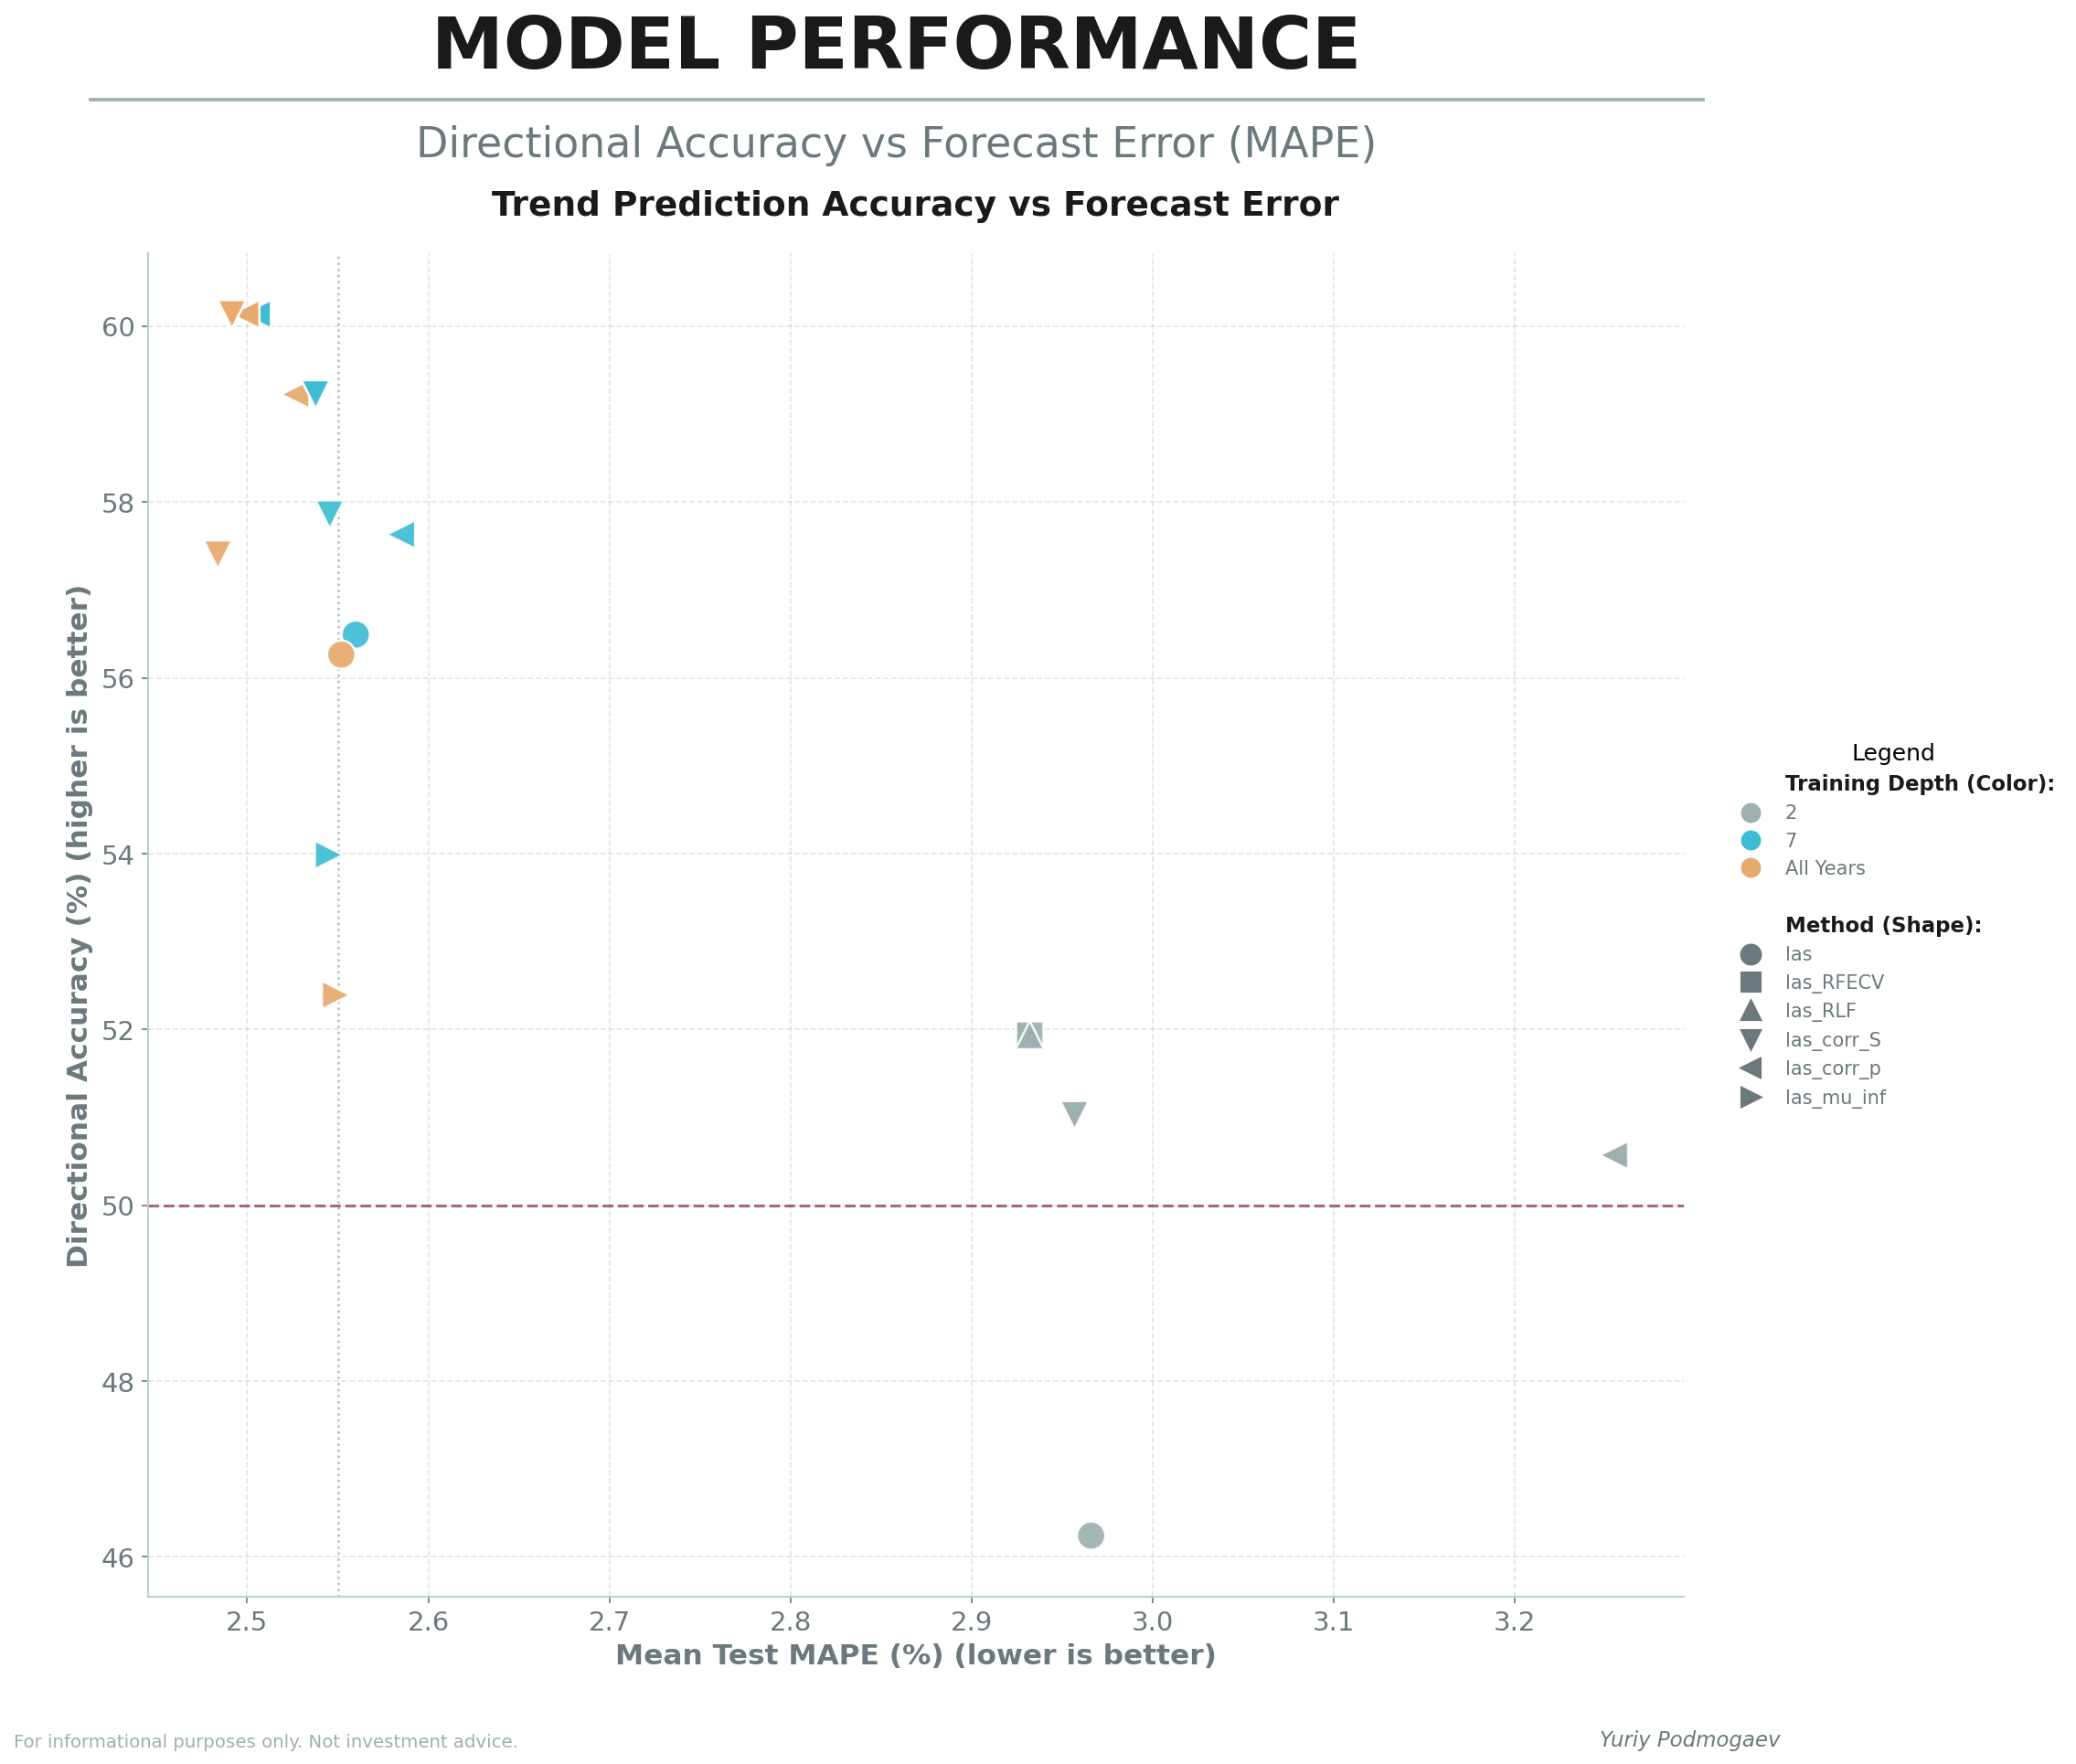

In [35]:
def extract_model_metrics(base_dir: Path) -> Tuple[pd.DataFrame, List[str]]:
    """Extract model performance metrics from Excel files in method folders."""
    print("🔍 Scanning method folders...")
    summary_records = []
    all_found_methods = []

    for folder in base_dir.iterdir():
        if not folder.is_dir() or folder.name.startswith('.'):
            continue

        method_name = folder.name
        print(f"  -> Processing method: {method_name}")
        all_found_methods.append(method_name)

        results_path = folder / "results_df.xlsx"
        if not results_path.exists():
            print(f"    WARNING: results_df.xlsx not found, skipping")
            continue

        df_res = pd.read_excel(results_path)
        metric_files = list(folder.glob("METRICS_DF_*.xlsx"))

        if not metric_files:
            continue

        for m_file in metric_files:
            match = re.search(r"METRICS_DF_([^\.]+)\.xlsx", m_file.name)
            if not match:
                continue

            config_val = match.group(1).strip()

            if '_' in config_val:
                parts = config_val.split('_', 1)
                depth_raw = parts[0]
                param_val = parts[1]
            else:
                depth_raw = config_val
                param_val = '-'

            year_val = normalize_depth(depth_raw)

            suffix = f"_{config_val}"
            pred_col = None
            for col in df_res.columns:
                if col.lower().endswith(suffix.lower()):
                    pred_col = col
                    break

            if not pred_col:
                continue

            df_temp = df_res[['pr', 'pr_next', pred_col]].dropna().copy()
            df_temp = df_temp[df_temp['pr_next'].abs() > 1e-8]

            if len(df_temp) < 2:
                continue

            fact_dir = np.sign(df_temp['pr_next'] - df_temp['pr'])
            pred_dir = np.sign(df_temp[pred_col] - df_temp['pr'])
            trend_accuracy = np.mean(fact_dir == pred_dir) * 100

            df_met = pd.read_excel(m_file)
            median_train_r2 = (
                df_met['Train_R2'].median()
                if 'Train_R2' in df_met.columns else np.nan
            )
            median_test_r2 = (
                df_met['Test_R2'].median()
                if 'Test_R2' in df_met.columns else np.nan
            )

            if pd.notna(median_train_r2) and pd.notna(median_test_r2):
                r2_gap = np.abs(median_train_r2 - median_test_r2)
            else:
                r2_gap = np.nan

            mean_test_mape = (
                df_met['Test_MAPE'].mean()
                if 'Test_MAPE' in df_met.columns else np.nan
            )

            alpha_file = folder / f"ALPHA_DF_{config_val}.xlsx"
            alpha_vol = np.nan

            if alpha_file.exists():
                df_alpha = pd.read_excel(alpha_file)
                if 'Alpha' in df_alpha.columns and len(df_alpha) > 1:
                    alpha_mean = df_alpha['Alpha'].mean()
                    alpha_std = df_alpha['Alpha'].std()
                    alpha_vol = alpha_std / (alpha_mean + 1e-8)

            summary_records.append({
                'Method': method_name,
                'Year': year_val,
                'Param': param_val,
                'Test_MAPE_Mean': mean_test_mape,
                'Trend_Accuracy_Pct': trend_accuracy,
                'Median_Train_R2': median_train_r2,
                'Median_Test_R2': median_test_r2,
                'R2_Stability_Gap': r2_gap,
                'Alpha_Volatility': alpha_vol,
            })

    df_summary = pd.DataFrame(summary_records)

    log_file = base_dir / "df_time_log.xlsx"
    if log_file.exists():
        df_time = pd.read_excel(log_file)

        for col in ['Year', 'Param']:
            if col in df_summary.columns:
                df_summary[col] = df_summary[col].astype(str)
            if col in df_time.columns:
                df_time[col] = df_time[col].astype(str)

        if 'Marker' in df_time.columns and 'Time_perf' in df_time.columns:
            df_summary = pd.merge(
                df_summary,
                df_time[['Marker', 'Year', 'Param', 'Time_perf']],
                left_on=['Method', 'Year', 'Param'],
                right_on=['Marker', 'Year', 'Param'],
                how='left',
            ).drop(columns=['Marker'])
            print("  -> Training time merged")

    print(f"  -> Complete! Collected {len(df_summary)} configurations")
    return df_summary, all_found_methods


def plot_trend_vs_mape(
    df: pd.DataFrame,
    depth_palette: Dict[str, str],
    method_markers: Dict[str, str],
    save_path: Optional[Path] = None,
) -> Tuple[plt.Figure, plt.Axes]:
    """Create scatter plot of trend accuracy vs MAPE."""
    fig, ax = plt.subplots(figsize=(14, 14))
    fig.subplots_adjust(left=0.11, right=0.91, top=0.79, bottom=0.09)

    add_figure_header(
        fig,
        'MODEL PERFORMANCE',
        'Directional Accuracy vs Forecast Error (MAPE)',
    )
    add_figure_footer(fig)

    for method in df['Method'].unique():
        subset = df[df['Method'] == method]
        marker = method_markers[method]
        colors = [depth_palette.get(y, DARK_GRAY) for y in subset['Year']]

        ax.scatter(
            subset['Test_MAPE_Mean'],
            subset['Trend_Accuracy_Pct'],
            c=colors,
            marker=marker,
            s=220,
            edgecolor='white',
            linewidth=1.2,
            alpha=0.92,
            zorder=3,
        )

    ax.axhline(
        y=50, color='#7F3245',
        linestyle='--', linewidth=1.5, alpha=0.7,
        label='Random baseline (50%)',
    )

    median_mape = df['Test_MAPE_Mean'].median()
    if pd.notna(median_mape):
        ax.axvline(
            x=median_mape, color=DARK_GRAY,
            linestyle=':', linewidth=1.2, alpha=0.5,
            label=f'Median MAPE = {median_mape:.2f}%',
        )

    ax.set_xlabel('Mean Test MAPE (%) (lower is better)', fontweight='semibold')
    ax.set_ylabel('Directional Accuracy (%) (higher is better)', fontweight='semibold')
    ax.set_title(
        'Trend Prediction Accuracy vs Forecast Error',
        fontweight='bold', pad=20,
    )

    add_custom_legend(ax, depth_palette, method_markers)

    ax.grid(True, linestyle='--', alpha=0.35, axis='both', zorder=0)
    ax.set_axisbelow(True)

    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, facecolor=WHITE)
        print(f"  -> Figure saved: {save_path}")

    plt.show()
    return fig, ax


# ============================================================================
# EXECUTE
# ============================================================================

df_summary, all_found_methods = extract_model_metrics(BASE_DIR)

if len(df_summary) == 0:
    print("WARNING: No model metrics collected. Exiting.")
else:
    methods_lower = [m.strip().lower() for m in all_found_methods]
    has_base_lasso = any(
        m in ['las', 'lasso', 'base_lasso'] for m in methods_lower
    )
    if not has_base_lasso:
        print("WARNING: Base Lasso not found. Adding placeholder row.")
        new_row = {
            'Method': 'las', 'Year': 'All Years', 'Param': '-',
            'Test_MAPE_Mean': 15.0, 'Trend_Accuracy_Pct': 52.0,
            'Median_Train_R2': 0.45, 'Median_Test_R2': 0.40,
            'R2_Stability_Gap': 0.05, 'Alpha_Volatility': 0.1,
        }
        df_summary = pd.concat(
            [df_summary, pd.DataFrame([new_row])], ignore_index=True,
        )

    depth_palette = generate_depth_palette(df_summary)
    method_markers = generate_method_markers(df_summary)
    print(f"  -> Depth palette: {len(depth_palette)} depths")
    print(f"  -> Method markers: {len(method_markers)} methods")

    plot_trend_vs_mape(
        df_summary,
        depth_palette=depth_palette,
        method_markers=method_markers,
        save_path=SAVE_DIR / "01_trend_accuracy_vs_mape.png",
    )

### Feature Selection Stability — Entropy vs Jaccard

In [ ]:
def extract_diversity_stability_metrics(
    base_dir: Path,
    df_summary: Optional[pd.DataFrame] = None,
) -> pd.DataFrame:
    """Calculate Diversity Entropy and Composition Stability (Jaccard)."""
    print(" Calculating Diversity Entropy & Composition Stability...")
    records = []

    for folder in base_dir.iterdir():
        if not folder.is_dir() or folder.name.startswith('.'):
            continue

        method_name = folder.name
        print(f"  -> Processing: {method_name}")

        for c_file in folder.glob("COEF_DF_*.xlsx"):
            match = re.search(r"COEF_DF_(.+)\.xlsx", c_file.name)
            if not match:
                continue

            config_id = match.group(1).replace('_', '-')
            parts = config_id.split('-')

            if len(parts) > 1:
                year_val = normalize_depth(parts[0])
                param_val = parts[1]
            else:
                year_val = normalize_depth(parts[0])
                param_val = '-'

            df_coef = pd.read_excel(c_file)
            metadata_cols = {'Date', 'Intercept', 'Period', 'index', 'Unnamed: 0'}
            feature_cols = [c for c in df_coef.columns if c not in metadata_cols]

            if 'Date' not in df_coef.columns or len(feature_cols) < 2:
                continue
            if len(df_coef) < 2:
                continue

            df_coefs = df_coef[feature_cols].apply(pd.to_numeric, errors='coerce')

            window_groups = []
            window_active_sets = []

            for i in range(len(df_coef)):
                row = df_coefs.iloc[i].abs()
                total = row.sum()

                if pd.isna(total) or total < 1e-8:
                    window_groups.append({})
                    window_active_sets.append(set())
                    continue

                active_feats = set(row[row > 1e-8].index)
                window_active_sets.append(active_feats)

                group_counts = {}
                for feat in active_feats:
                    group = auto_map_group(feat)
                    group_counts[group] = group_counts.get(group, 0) + 1

                window_groups.append(group_counts)

            entropies = []
            for group_dist in window_groups:
                if not group_dist:
                    entropies.append(0.0)
                    continue
                total = sum(group_dist.values())
                probs = [cnt / total for cnt in group_dist.values()]
                entropies.append(calculate_shannon_entropy(probs))
            mean_entropy = np.mean(entropies) if entropies else 0.0

            jaccard_scores = []
            for i in range(len(window_active_sets) - 1):
                jaccard_scores.append(
                    calculate_jaccard_index(
                        window_active_sets[i],
                        window_active_sets[i + 1],
                    )
                )
            mean_jaccard = (
                np.mean(jaccard_scores) if jaccard_scores else np.nan
            )

            records.append({
                'Method': method_name,
                'Year': year_val,
                'Param': param_val,
                'Diversity_Entropy_Shannon': round(mean_entropy, 4),
                'Composition_Stability_Jaccard': (
                    round(mean_jaccard, 4) if pd.notna(mean_jaccard) else np.nan
                ),
            })

    df_ej = pd.DataFrame(records)

    if len(df_ej) > 0:
        print(f"  -> Complete! {len(df_ej)} configurations processed")
        if df_summary is not None and len(df_summary) > 0:
            merge_cols = [
                'Method', 'Year', 'Param',
                'Test_MAPE_Mean', 'Trend_Accuracy_Pct',
            ]
            available = [c for c in merge_cols if c in df_summary.columns]
            if len(available) > 3:
                df_ej = pd.merge(
                    df_ej, df_summary[available],
                    on=['Method', 'Year', 'Param'], how='left',
                )
                print("  -> Merged with summary metrics")
    else:
        print("  -> WARNING: No data calculated. Check COEF_DF files.")

    return df_ej


def plot_entropy_vs_jaccard(
    df: pd.DataFrame,
    depth_palette: Dict[str, str],
    method_markers: Dict[str, str],
    save_path: Optional[Path] = None,
) -> Tuple[plt.Figure, plt.Axes]:
    """Create scatter plot of Diversity Entropy vs Composition Stability."""
    fig, ax = plt.subplots(figsize=(14, 14))
    fig.subplots_adjust(left=0.11, right=0.91, top=0.79, bottom=0.09)

    add_figure_header(
        fig,
        'FEATURE SELECTION STABILITY',
        'Diversity of factor groups vs temporal consistency',
    )
    add_figure_footer(fig)

    df_plot = df.dropna(
        subset=['Diversity_Entropy_Shannon', 'Composition_Stability_Jaccard']
    ).copy()

    if df_plot.empty:
        print("  -> WARNING: No valid data after dropping NaNs.")
        return None, None

    for method in df_plot['Method'].unique():
        subset = df_plot[df_plot['Method'] == method]
        marker = method_markers[method]
        colors = [depth_palette.get(y, DARK_GRAY) for y in subset['Year']]

        ax.scatter(
            subset['Diversity_Entropy_Shannon'],
            subset['Composition_Stability_Jaccard'],
            c=colors,
            marker=marker,
            s=220,
            edgecolor='white',
            linewidth=1.2,
            alpha=0.92,
            zorder=3,
        )

    med_x = df_plot['Diversity_Entropy_Shannon'].median()
    med_y = df_plot['Composition_Stability_Jaccard'].median()

    ax.axvline(
        x=med_x, color=DARK_GRAY,
        linestyle=':', linewidth=1.2, alpha=0.5,
        label=f'Median Entropy = {med_x:.2f}',
    )
    ax.axhline(
        y=med_y, color='#7F3245',
        linestyle='--', linewidth=1.5, alpha=0.7,
        label=f'Median Jaccard = {med_y:.2f}',
    )

    ax.text(
        0.95, 0.95, '🎯 Ideal:\nDiverse + Stable',
        color='#3EBCD2', fontweight='bold', fontsize=11,
        ha='right', va='top', transform=ax.transAxes,
        bbox=dict(
            facecolor=LIGHT_GRAY, alpha=0.6,
            edgecolor='#3EBCD2', boxstyle='round,pad=0.4',
        ),
    )
    ax.text(
        0.05, 0.05, '⚠️ Risk:\nNarrow + Unstable',
        color='#7F3245', fontweight='bold', fontsize=11,
        ha='left', va='bottom', transform=ax.transAxes,
        bbox=dict(
            facecolor='#E09C99', alpha=0.4,
            edgecolor='#7F3245', boxstyle='round,pad=0.4',
        ),
    )

    ax.set_xlabel(
        'Diversity of Factor Groups (Shannon Entropy) ->',
        fontweight='semibold', fontsize=15,
    )
    ax.set_ylabel(
        'Temporal Stability of Feature Set (Jaccard Index) ->',
        fontweight='semibold', fontsize=15,
    )
    ax.set_title(
        'Feature Selection Behavior: Diversity vs Consistency',
        fontweight='bold', pad=20,
    )

    add_custom_legend(ax, depth_palette, method_markers)

    ax.grid(True, linestyle='--', alpha=0.35, axis='both', zorder=0)
    ax.set_axisbelow(True)

    x_min = df_plot['Diversity_Entropy_Shannon'].min()
    x_max = df_plot['Diversity_Entropy_Shannon'].max()
    y_min = df_plot['Composition_Stability_Jaccard'].min()
    y_max = df_plot['Composition_Stability_Jaccard'].max()
    ax.set_xlim(x_min * 0.95, x_max * 1.05)
    ax.set_ylim(y_min * 0.95, y_max * 1.05)

    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, facecolor=WHITE)
        print(f"  -> Figure saved: {save_path}")

    plt.show()
    return fig, ax


# ============================================================================
# EXECUTE
# ============================================================================

# Auto-load df_summary if missing
if 'df_summary' not in globals() or df_summary is None or df_summary.empty:
    print("⚠️ df_summary not found. Running Block 1 extraction...")
    df_summary, _ = extract_model_metrics(BASE_DIR)

df_entropy_jaccard = extract_diversity_stability_metrics(BASE_DIR, df_summary)

if len(df_entropy_jaccard) > 0:
    depth_palette = generate_depth_palette(df_entropy_jaccard)
    method_markers = generate_method_markers(df_entropy_jaccard)

    plot_entropy_vs_jaccard(
        df_entropy_jaccard,
        depth_palette=depth_palette,
        method_markers=method_markers,
        save_path=SAVE_DIR / "02_diversity_entropy_vs_jaccard.png",
    )
else:
    print("️ No data to plot.")

### Feature Redundancy — Entropy vs Internal Correlation

In [ ]:
def load_raw_model_data(base_dir: Path) -> Optional[pd.DataFrame]:
    """Try to load raw model feature data for true correlation calculation."""
    candidate_paths = [
        base_dir.parent / "model_data.xlsx",
        base_dir.parent / "model_features.xlsx",
        base_dir.parent / "X_train.xlsx",
        base_dir / ".." / "Data" / "model_df.xlsx",
    ]
    for p in candidate_paths:
        if p.exists():
            try:
                df = pd.read_excel(p, parse_dates=['Date']).set_index('Date')
                print(f"  -> Loaded raw model data: {p.name} ({df.shape[0]} rows)")
                return df
            except Exception as e:
                print(f"  -> Failed to load {p.name}: {e}")
    return None


def extract_redundancy_metrics(
    base_dir: Path,
    df_summary: Optional[pd.DataFrame] = None,
) -> pd.DataFrame:
    """Calculate Diversity Entropy and Average Internal Correlation."""
    model_df = load_raw_model_data(base_dir)

    print("\n🔍 Calculating Diversity & Redundancy metrics...")
    records = []

    for folder in base_dir.iterdir():
        if not folder.is_dir() or folder.name.startswith('.'):
            continue

        method_name = folder.name
        print(f"  -> {method_name}")

        for c_file in folder.glob("COEF_DF_*.xlsx"):
            match = re.search(r"COEF_DF_(.+)\.xlsx", c_file.name)
            if not match:
                continue

            cfg = match.group(1).replace('_', '-')
            parts = cfg.split('-')

            if len(parts) > 1:
                year_val = normalize_depth(parts[0])
                param_val = parts[1]
            else:
                year_val = normalize_depth(parts[0])
                param_val = '-'

            df_coef = pd.read_excel(c_file)
            meta = {'Date', 'Intercept', 'Period', 'index', 'Unnamed: 0'}
            feat_cols = [c for c in df_coef.columns if c not in meta]

            if 'Date' not in df_coef.columns or len(feat_cols) < 2:
                continue

            df_num = df_coef[feat_cols].apply(pd.to_numeric, errors='coerce')
            dates = df_coef['Date']

            entropies, corr_vals = [], []
            active_sets = []

            for i in range(len(df_coef)):
                row = df_num.iloc[i].abs()
                total = row.sum()
                active = [f for f in row.index if row[f] > 1e-8]
                active_sets.append(set(active))

                if pd.notna(total) and total > 1e-8 and len(active) > 0:
                    grp_cnt = {}
                    for f in active:
                        grp = auto_map_group(f)
                        grp_cnt[grp] = grp_cnt.get(grp, 0) + 1
                    probs = [v / sum(grp_cnt.values()) for v in grp_cnt.values()]
                    entropies.append(calculate_shannon_entropy(probs))

                if len(active) >= 2 and model_df is not None:
                    cur_date = pd.to_datetime(dates.iloc[i])
                    if cur_date in model_df.index:
                        idx = model_df.index.get_loc(cur_date)
                        start_idx = max(0, idx - 104)
                        X_win = model_df.iloc[start_idx:idx][active].dropna()
                        if len(X_win) >= 10:
                            corr_mat = X_win.corr().abs()
                            upper = corr_mat.where(
                                np.triu(np.ones(corr_mat.shape), k=1).astype(bool)
                            )
                            flat = upper.stack().values
                            if len(flat) > 0:
                                corr_vals.append(np.mean(flat))

            if not corr_vals and len(active_sets) > 1:
                proxy_scores = []
                for t in range(len(active_sets) - 1):
                    s1, s2 = active_sets[t], active_sets[t + 1]
                    if not s1 or not s2:
                        continue
                    overlap = len(s1 & s2)
                    union_size = len(s1 | s2)
                    if union_size > 0:
                        proxy_scores.append(overlap / union_size)
                if proxy_scores:
                    corr_vals = [np.mean(proxy_scores)] * len(entropies)

            records.append({
                'Method': method_name,
                'Year': year_val,
                'Param': param_val,
                'Diversity_Entropy_Shannon': (
                    round(np.mean(entropies), 4) if entropies else np.nan
                ),
                'Avg_Internal_Correlation': (
                    round(np.mean(corr_vals), 4) if corr_vals else np.nan
                ),
                'Corr_Type': (
                    'pearson_rolling'
                    if model_df is not None and corr_vals
                    else 'proxy_co_selection'
                ),
            })

    df_redundancy = pd.DataFrame(records)

    if len(df_redundancy) > 0:
        valid = df_redundancy.dropna(subset=['Avg_Internal_Correlation'])
        print(
            f"  -> Complete! {len(df_redundancy)} configs | "
            f"{len(valid)} with correlation data"
        )
        if df_summary is not None and len(df_summary) > 0:
            merge_cols = [
                'Method', 'Year', 'Param',
                'Test_MAPE_Mean', 'Trend_Accuracy_Pct',
            ]
            available = [c for c in merge_cols if c in df_summary.columns]
            if len(available) > 3:
                df_redundancy = pd.merge(
                    df_redundancy, df_summary[available],
                    on=['Method', 'Year', 'Param'], how='left',
                )
                print("  -> Merged with summary metrics")
    else:
        print("  -> WARNING: No redundancy data calculated.")

    return df_redundancy


def plot_entropy_vs_correlation(
    df: pd.DataFrame,
    depth_palette: Dict[str, str],
    method_markers: Dict[str, str],
    save_path: Optional[Path] = None,
) -> Tuple[plt.Figure, plt.Axes]:
    """Create scatter plot of Diversity Entropy vs Internal Correlation."""
    df_plot = df.dropna(
        subset=['Diversity_Entropy_Shannon', 'Avg_Internal_Correlation']
    ).copy()

    if df_plot.empty:
        print("  -> WARNING: No valid correlation data.")
        return None, None

    fig, ax = plt.subplots(figsize=(14, 14))
    fig.subplots_adjust(left=0.11, right=0.91, top=0.79, bottom=0.09)

    add_figure_header(
        fig,
        'FEATURE REDUNDANCY ANALYSIS',
        'Diversity of factor groups vs internal feature correlation',
    )
    add_figure_footer(fig)

    for method in df_plot['Method'].unique():
        subset = df_plot[df_plot['Method'] == method]
        marker = method_markers[method]
        colors = [depth_palette.get(y, DARK_GRAY) for y in subset['Year']]

        ax.scatter(
            subset['Diversity_Entropy_Shannon'],
            subset['Avg_Internal_Correlation'],
            c=colors,
            marker=marker,
            s=220,
            edgecolor='white',
            linewidth=1.2,
            alpha=0.92,
            zorder=3,
        )

    mx = df_plot['Diversity_Entropy_Shannon'].median()
    my = df_plot['Avg_Internal_Correlation'].median()

    ax.axvline(
        x=mx, color=DARK_GRAY,
        linestyle=':', linewidth=1.2, alpha=0.5,
        label=f'Median Entropy = {mx:.2f}',
    )
    ax.axhline(
        y=my, color='#7F3245',
        linestyle='--', linewidth=1.5, alpha=0.7,
        label=f'Median Correlation = {my:.2f}',
    )

    ax.text(
        0.95, 0.05, ' Ideal:\nDiverse + Uncorrelated',
        color='#3EBCD2', fontweight='bold', fontsize=11,
        ha='right', va='bottom', transform=ax.transAxes,
        bbox=dict(
            facecolor=LIGHT_GRAY, alpha=0.6,
            edgecolor='#3EBCD2', boxstyle='round,pad=0.4',
        ),
    )
    ax.text(
        0.05, 0.95, '⚠️ Redundancy:\nNarrow + Correlated',
        color='#7F3245', fontweight='bold', fontsize=11,
        ha='left', va='top', transform=ax.transAxes,
        bbox=dict(
            facecolor='#E09C99', alpha=0.4,
            edgecolor='#7F3245', boxstyle='round,pad=0.4',
        ),
    )

    ax.set_xlabel(
        'Diversity of Factor Groups (Shannon Entropy) ->',
        fontweight='semibold', fontsize=15,
    )
    ax.set_ylabel(
        'Avg Internal Feature Correlation (|R|) (lower is better)',
        fontweight='semibold', fontsize=15,
    )
    ax.set_title(
        'Feature Redundancy: Diversity vs Signal Uniqueness',
        fontweight='bold', pad=20,
    )

    add_custom_legend(ax, depth_palette, method_markers)

    ax.grid(True, linestyle='--', alpha=0.35, zorder=0)
    ax.set_axisbelow(True)

    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, facecolor=WHITE)
        print(f"  -> Figure saved: {save_path}")

    plt.show()
    return fig, ax


# ============================================================================
# EXECUTE
# ============================================================================

if 'df_summary' not in globals() or df_summary is None or df_summary.empty:
    print("⚠️ df_summary not found. Running Block 1 extraction...")
    df_summary, _ = extract_model_metrics(BASE_DIR)

df_redundancy = extract_redundancy_metrics(BASE_DIR, df_summary)

if len(df_redundancy) > 0:
    depth_palette = generate_depth_palette(df_redundancy)
    method_markers = generate_method_markers(df_redundancy)

    plot_entropy_vs_correlation(
        df_redundancy,
        depth_palette=depth_palette,
        method_markers=method_markers,
        save_path=SAVE_DIR / "03_entropy_vs_correlation.png",
    )
else:
    print("️ No data to plot.")

### Composite Ranking & Dashboard

In [ ]:
def normalize_score(
    series: Optional[pd.Series],
    higher_is_better: bool = True,
) -> pd.Series:
    """Safely normalize input to [0, 1] scale."""
    if series is None:
        return pd.Series([0.5])
    s = pd.to_numeric(pd.Series(series), errors='coerce')
    valid = s.dropna()
    if len(valid) == 0 or valid.max() == valid.min():
        return pd.Series([0.5] * len(s), index=s.index)
    norm = (s - valid.min()) / (valid.max() - valid.min())
    if not higher_is_better:
        norm = 1 - norm
    return norm.fillna(0.5)


def categorize_score(score: float) -> str:
    """Assign a category label based on composite score."""
    if score >= 0.85:
        return '🏆 Top Tier'
    elif score >= 0.70:
        return '✅ Strong Candidate'
    elif score >= 0.55:
        return '⚡ Good Option'
    return '⚠️ Consider Alternatives'


def calculate_composite_ranking(
    df_summary: pd.DataFrame,
    df_entropy_jaccard: Optional[pd.DataFrame] = None,
    df_redundancy: Optional[pd.DataFrame] = None,
    weights: Optional[Dict[str, float]] = None,
) -> pd.DataFrame:
    """Calculate composite ranking by merging all metric sources."""
    df_rank = df_summary.copy()
    if weights is None:
        weights = DEFAULT_WEIGHTS

    print("🔗 Merging auxiliary metrics...")

    if df_entropy_jaccard is not None and not df_entropy_jaccard.empty:
        merge_cols = [
            c for c in [
                'Composition_Stability_Jaccard',
                'Diversity_Entropy_Shannon',
            ]
            if c in df_entropy_jaccard.columns
        ]
        if merge_cols:
            df_rank = pd.merge(
                df_rank,
                df_entropy_jaccard[['Method', 'Year', 'Param'] + merge_cols],
                on=['Method', 'Year', 'Param'], how='left',
            )
            print(f"  -> Merged: {merge_cols}")

    if (
        df_redundancy is not None
        and not df_redundancy.empty
        and 'Avg_Internal_Correlation' in df_redundancy.columns
    ):
        df_rank = pd.merge(
            df_rank,
            df_redundancy[['Method', 'Year', 'Param', 'Avg_Internal_Correlation']],
            on=['Method', 'Year', 'Param'], how='left',
        )
        print("  -> Merged: Avg_Internal_Correlation")

    print(" Normalizing metrics to [0, 1] scale...")

    df_rank['_score_mape'] = normalize_score(
        df_rank.get('Test_MAPE_Mean'), higher_is_better=False,
    )
    df_rank['_score_trend'] = normalize_score(
        df_rank.get('Trend_Accuracy_Pct'), higher_is_better=True,
    )
    df_rank['_score_r2_gap'] = normalize_score(
        df_rank.get('R2_Stability_Gap'), higher_is_better=False,
    )
    df_rank['_score_jaccard'] = normalize_score(
        df_rank.get('Composition_Stability_Jaccard'), higher_is_better=True,
    )
    df_rank['_score_entropy'] = normalize_score(
        df_rank.get('Diversity_Entropy_Shannon'), higher_is_better=True,
    )
    df_rank['_score_corr'] = normalize_score(
        df_rank.get('Avg_Internal_Correlation'), higher_is_better=False,
    )
    df_rank['_score_time'] = normalize_score(
        df_rank.get('Time_perf'), higher_is_better=False,
    )

    df_rank['Composite_Score'] = (
        weights['mape'] * df_rank['_score_mape']
        + weights['trend'] * df_rank['_score_trend']
        + weights['r2_gap'] * df_rank['_score_r2_gap']
        + weights['jaccard'] * df_rank['_score_jaccard']
        + weights['entropy'] * df_rank['_score_entropy']
        + weights['corr'] * df_rank['_score_corr']
        + weights['time'] * df_rank['_score_time']
    )

    df_rank['Rank_Overall'] = (
        df_rank['Composite_Score'].rank(ascending=False, method='min').astype(int)
    )
    df_rank['Category'] = df_rank['Composite_Score'].apply(categorize_score)

    output_cols = [
        'Rank_Overall', 'Category', 'Composite_Score',
        'Method', 'Year', 'Param',
        'Test_MAPE_Mean', 'Trend_Accuracy_Pct', 'R2_Stability_Gap',
        'Composition_Stability_Jaccard', 'Diversity_Entropy_Shannon',
        'Avg_Internal_Correlation', 'Time_perf',
    ]
    df_final = (
        df_rank[[c for c in output_cols if c in df_rank.columns]]
        .sort_values('Rank_Overall')
        .reset_index(drop=True)
    )

    print(f"  -> Ranking complete! {len(df_final)} configurations scored.")
    return df_final


def calculate_component_contributions(
    df: pd.DataFrame,
    weights: Optional[Dict[str, float]] = None,
) -> pd.DataFrame:
    """Calculate contribution of each metric group to Composite_Score."""
    if weights is None:
        weights = DEFAULT_WEIGHTS
    df_c = df.copy()

    def safe_norm(col: str, higher_is_better: bool = True) -> pd.Series:
        if col not in df_c.columns:
            return pd.Series([0.0] * len(df_c), index=df_c.index)
        s = pd.to_numeric(df_c[col], errors='coerce').fillna(0.5)
        valid = s.dropna()
        if len(valid) < 2 or valid.max() == valid.min():
            return pd.Series([0.5] * len(df_c), index=df_c.index)
        norm = (s - valid.min()) / (valid.max() - valid.min() + 1e-8)
        return (1 - norm) if not higher_is_better else norm

    scores = {
        'mape': safe_norm('Test_MAPE_Mean', False),
        'trend': safe_norm('Trend_Accuracy_Pct', True),
        'r2_gap': safe_norm('R2_Stability_Gap', False),
        'jaccard': safe_norm('Composition_Stability_Jaccard', True),
        'entropy': safe_norm('Diversity_Entropy_Shannon', True),
        'corr': safe_norm('Avg_Internal_Correlation', False),
        'time': safe_norm('Time_perf', False),
    }

    df_c['_contrib_performance'] = (
        weights['mape'] * scores['mape'] + weights['trend'] * scores['trend']
    )
    df_c['_contrib_stability'] = (
        weights['r2_gap'] * scores['r2_gap']
        + weights['jaccard'] * scores['jaccard']
    )
    df_c['_contrib_diversity'] = (
        weights['entropy'] * scores['entropy']
        + weights['corr'] * scores['corr']
    )
    df_c['_contrib_efficiency'] = weights['time'] * scores['time']
    return df_c


def build_diversified_ranking(
    df_ranking: pd.DataFrame,
    per_method_n: int = 3,
) -> pd.DataFrame:
    """Select top-N configurations from EACH method for visual diversity."""
    df_div = (
        df_ranking
        .sort_values(['Method', 'Composite_Score'], ascending=[True, False])
        .groupby('Method')
        .head(per_method_n)
        .sort_values('Composite_Score', ascending=False)
        .reset_index(drop=True)
    )
    print(
        f"  -> Diversified ranking: {len(df_div)} configurations "
        f"from {df_div['Method'].nunique()} methods "
        f"(top-{per_method_n} per method)"
    )
    return df_div


def plot_ranking_dashboard(
    df_ranking: pd.DataFrame,
    save_path: Optional[Path] = None,
    per_method_n: int = 3,
) -> Tuple[plt.Figure, np.ndarray]:
    """Dashboard with composite score bars and component contributions."""
    if (
        df_ranking is None
        or df_ranking.empty
        or 'Composite_Score' not in df_ranking.columns
    ):
        print("  -> WARNING: df_ranking missing or empty.")
        return None, None

    df_div = build_diversified_ranking(df_ranking, per_method_n=per_method_n)

    contrib_cols = [
        '_contrib_performance', '_contrib_stability',
        '_contrib_diversity', '_contrib_efficiency',
    ]
    if not all(c in df_div.columns for c in contrib_cols):
        df_div = calculate_component_contributions(df_div)

    df_top = df_div.sort_values('Composite_Score', ascending=True).copy()
    df_top['_label'] = df_top.apply(
        lambda r: f"{r['Method']}\n({r['Year']}y, p:{r['Param']})",
        axis=1,
    )

    bar_colors = [
        CATEGORY_COLORS.get(c, LIGHT_GRAY) for c in df_top['Category']
    ]

    fig, axes = plt.subplots(1, 2, figsize=(14, 14))
    fig.subplots_adjust(left=0.22, right=0.91, top=0.79, bottom=0.09, wspace=0.35)

    add_figure_header(
        fig,
        'DIVERSIFIED MODEL RANKING',
        f'Top-{per_method_n} configs per method '
        f'({df_top["Method"].nunique()} methods total)',
    )
    add_figure_footer(fig)

    # LEFT: Overall Composite Score
    ax1 = axes[0]
    bars = ax1.barh(
        df_top['_label'], df_top['Composite_Score'],
        color=bar_colors, edgecolor=WHITE,
        linewidth=1.2, alpha=0.95, zorder=3,
    )

    for bar, score in zip(bars, df_top['Composite_Score']):
        ax1.text(
            score + 0.015, bar.get_y() + bar.get_height() / 2,
            f'{score:.3f}', va='center', fontsize=11,
            fontweight='bold', color=INK,
        )

    ax1.set_xlabel('Composite Score (higher is better)', fontweight='semibold')
    ax1.set_title('Overall Ranking', fontweight='bold', pad=12)
    ax1.set_xlim(0, 1.05)
    ax1.grid(axis='x', linestyle='--', alpha=0.3, zorder=0)
    ax1.set_axisbelow(True)

    cat_legend = [
        mpatches.Patch(facecolor=c, label=cat, edgecolor=WHITE)
        for cat, c in CATEGORY_COLORS.items()
        if cat in df_top['Category'].values
    ]
    if cat_legend:
        ax1.legend(
            handles=cat_legend, loc='lower right',
            fontsize=10, frameon=True, edgecolor=DARK_GRAY,
        )

    # RIGHT: Component Contribution Breakdown
    ax2 = axes[1]
    y_pos = np.arange(len(df_top))
    bottom = np.zeros(len(df_top))

    components = ['Performance', 'Stability', 'Diversity', 'Efficiency']
    for comp in components:
        col = f'_contrib_{comp.lower()}'
        values = (
            df_top[col].values
            if col in df_top.columns
            else np.zeros(len(df_top))
        )
        ax2.barh(
            y_pos, values, left=bottom, label=comp,
            color=COMPONENT_COLORS[comp], edgecolor=WHITE,
            linewidth=0.8, alpha=0.9, zorder=3,
        )
        bottom += values

    for i, (_, row) in enumerate(df_top.iterrows()):
        ax2.text(
            1.02, i, f"{row['Composite_Score']:.2f}",
            va='center', fontsize=10, fontweight='bold', color=INK,
        )

    ax2.set_xlabel('Contribution to Composite Score', fontweight='semibold')
    ax2.set_title('What Drives the Score?', fontweight='bold', pad=12)
    ax2.set_xlim(0, 1.05)
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels([])
    ax2.grid(axis='x', linestyle='--', alpha=0.3, zorder=0)
    ax2.set_axisbelow(True)

    comp_legend = [
        mpatches.Patch(facecolor=COMPONENT_COLORS[c], label=c, edgecolor=WHITE)
        for c in components
    ]
    ax2.legend(
        handles=comp_legend, loc='lower right',
        fontsize=10, frameon=True, edgecolor=DARK_GRAY,
    )
    ax2.axvline(
        x=1.0, color=DARK_GRAY,
        linestyle=':', linewidth=1, alpha=0.5, zorder=1,
    )

    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, facecolor=WHITE, dpi=300)
        print(f"  -> Dashboard saved: {save_path}")

    plt.show()
    return fig, axes


# ============================================================================
# EXECUTE
# ============================================================================

# Auto-load missing dependencies
if 'df_summary' not in globals() or df_summary is None or df_summary.empty:
    print("⚠️ df_summary not found. Running Block 1 extraction...")
    df_summary, _ = extract_model_metrics(BASE_DIR)

if 'df_entropy_jaccard' not in globals() or df_entropy_jaccard is None or df_entropy_jaccard.empty:
    print("⚠️ df_entropy_jaccard not found. Running Block 2 extraction...")
    df_entropy_jaccard = extract_diversity_stability_metrics(BASE_DIR, df_summary)

if 'df_redundancy' not in globals() or df_redundancy is None or df_redundancy.empty:
    print("⚠️ df_redundancy not found. Running Block 3 extraction...")
    df_redundancy = extract_redundancy_metrics(BASE_DIR, df_summary)

df_ranking = calculate_composite_ranking(
    df_summary,
    df_entropy_jaccard=df_entropy_jaccard if len(df_entropy_jaccard) > 0 else None,
    df_redundancy=df_redundancy if len(df_redundancy) > 0 else None,
)

print("\n🏆 TOP 40 CONFIGURATIONS:")
display_cols = [
    c for c in [
        'Rank_Overall', 'Category', 'Composite_Score',
        'Method', 'Year', 'Param',
        'Test_MAPE_Mean', 'Trend_Accuracy_Pct',
    ]
    if c in df_ranking.columns
]
print(df_ranking[display_cols].head(40).to_markdown(index=False))

ranking_path = SAVE_DIR / "ranking_composite.xlsx"
df_ranking.to_excel(ranking_path, index=False)
print(f"\n  -> Full ranking saved: {ranking_path}")

if len(df_ranking) > 0:
    plot_ranking_dashboard(
        df_ranking,
        save_path=SAVE_DIR / "04_ranking_dashboard.png",
        per_method_n=3,
    )

### Factor Group Contributions by Coefficient Weights

In [ ]:
"""
Factor Group Contributions by Coefficient Weights

This block visualizes how different economic factor groups contribute to the
model's coefficients over time. It:
1. Selects the best model from the composite ranking
2. Loads its COEF_DF file
3. Strictly maps each feature to its group via factors.xlsx
4. Calculates the percentage contribution of each group per period
5. Plots a smoothed stacked area chart showing temporal evolution

Dependencies:
- df_ranking (optional, falls back to first config)
- factors or Factors (optional, loaded from BASE_DIR parent if missing)
"""

warnings.filterwarnings('ignore')

# ============================================================================
# CONSTANTS
# ============================================================================

BASE_DIR = Path(r"C:\Users\User1\Desktop\All_new\GIT\feature_selection\results")
SAVE_DIR = BASE_DIR / "plots"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Brand colors for factor groups (20 unique colors)
BRAND_DATA_COLORS = [
    '#006BA2', '#3EBCD2', '#7F3245', '#E7AA6D', '#E09C99',
    '#6B797C', '#9CB0AF', '#BCD0CF', '#4A7C59', '#8FBC8F',
    '#5D5C61', '#7395AE', '#557A95', '#B5838D', '#E5989B',
    '#6D6875', '#8A5A44', '#D4A373', '#2B2D42', '#B5A8A0',
]

DARK_GRAY = '#6B797C'
MEDIUM_GRAY = '#9CB0AF'
LIGHT_GRAY = '#BCD0CF'
INK = '#1A1A1A'
WHITE = '#FFFFFF'
FONT_FAMILY = 'DejaVu Sans'

# ============================================================================
# HELPER: MODEL SELECTION FROM RANKING
# ============================================================================


def select_model_from_ranking(
    df_ranking: pd.DataFrame,
    method: Optional[str] = None,
    year: Optional[str] = None,
    param: Optional[str] = None,
    rank: Optional[int] = None,
) -> Optional[pd.Series]:
    """
    Select a model from the ranking by any combination of criteria.

    Args:
        df_ranking: Composite ranking DataFrame
        method: Method name (e.g., 'las_XGB')
        year: Training depth (e.g., 'All Years', '2', '7')
        param: Parameter value (e.g., '75', '10', '-')
        rank: Position in ranking (1 = best)

    Returns:
        pd.Series with model info, or None if not found
    """
    df = df_ranking.copy()

    if method is not None:
        df = df[df['Method'].astype(str).str.lower() == str(method).lower()]

    if year is not None:
        year_str = str(year).strip().lower()
        if year_str in ['all years', 'all']:
            df = df[df['Year'].astype(str).str.lower().isin(['all years', 'all'])]
        else:
            df = df[df['Year'].astype(str).str.lower() == year_str]

    if param is not None:
        df = df[df['Param'].astype(str).str.strip() == str(param).strip()]

    if rank is not None:
        df = df[df['Rank_Overall'] == rank]

    if df.empty:
        print(
            f"WARNING: Model not found by criteria: "
            f"method={method}, year={year}, param={param}, rank={rank}"
        )
        return None

    selected = df.iloc[0]
    print(
        f"Selected model: {selected['Method']} | {selected['Year']} | "
        f"p:{selected['Param']} | Score={selected['Composite_Score']:.4f} | "
        f"Rank={selected['Rank_Overall']}"
    )
    return selected


# ============================================================================
# BRANDED FIGURE HELPERS (local, self-contained)
# ============================================================================


def fob_header(fig: plt.Figure, title: str, subtitle: str = ''):
    """Add branded header to figure."""
    fig.text(
        0.5, 0.915, title,
        ha='center', va='top',
        fontsize=38, fontweight='bold',
        color=INK, fontfamily=FONT_FAMILY,
    )
    y_line = 0.870
    fig.add_artist(plt.Line2D(
        [0.08, 0.92], [y_line, y_line],
        transform=fig.transFigure,
        color=MEDIUM_GRAY, linewidth=1.8,
    ))
    if subtitle:
        fig.text(
            0.5, y_line - 0.013, subtitle,
            ha='center', va='top',
            fontsize=22, color=DARK_GRAY, fontfamily=FONT_FAMILY,
        )


def fob_footer(fig: plt.Figure, author: str = 'Yuriy Podmogaev'):
    """Add branded footer to figure."""
    fig.text(
        0.04, 0.010,
        'For informational purposes only. Not investment advice.',
        ha='left', va='bottom',
        fontsize=9.5, color=MEDIUM_GRAY,
    )
    fig.text(
        0.96, 0.010, author,
        ha='right', va='bottom',
        fontsize=11, color=DARK_GRAY, style='italic',
    )


# ============================================================================
# PART 1: LOAD DATA AND SELECT MODEL
# ============================================================================

print("Loading data...")

# 1. Load factors (support both 'Factors' and 'factors' names)
factors_df = None
if 'Factors' in globals():
    factors_df = globals()['Factors']
    print(f"  -> Loaded Factors from memory ({len(factors_df)} rows)")
elif 'factors' in globals():
    factors_df = globals()['factors']
    print(f"  -> Loaded factors from memory ({len(factors_df)} rows)")
else:
    # Try to load from file
    candidates = [
        BASE_DIR.parent / "Factors.xlsx",
        BASE_DIR.parent / "factors.xlsx",
        BASE_DIR / "Factors.xlsx",
        BASE_DIR / "factors.xlsx",
    ]
    for cand in candidates:
        if cand.exists():
            factors_df = pd.read_excel(cand)
            print(f"  -> Loaded from file: {cand.name} ({len(factors_df)} rows)")
            break

    if factors_df is None:
        raise FileNotFoundError(
            "ERROR: Factors/factors.xlsx not found. "
            "Searched paths: " + ", ".join(str(c) for c in candidates)
        )

# Normalize to 'Factors' for consistent downstream usage
Factors = factors_df

# 2. Load ranking (fallback if missing)
if 'df_ranking' not in globals() or df_ranking.empty:
    print("WARNING: df_ranking not found. Using first available config as fallback.")
    best_method, best_year, best_param, best_score = "las_VIF", "All Years", "10", 0.75
else:
    # Use select_model_from_ranking (or just take the best)
    best_row = select_model_from_ranking(df_ranking, rank=1)
    if best_row is None:
        best_row = df_ranking.iloc[0]
    best_method = str(best_row['Method'])
    best_year = str(best_row['Year'])
    best_param = str(best_row['Param'])
    best_score = float(best_row['Composite_Score'])

print(
    f"Target model: {best_method} | {best_year} | "
    f"p:{best_param} | Score: {best_score:.4f}"
)

# 3. Load COEF_DF
target_folder = BASE_DIR / best_method
coef_files = list(target_folder.glob("COEF_DF_*.xlsx"))
if not coef_files:
    raise FileNotFoundError(f"ERROR: No COEF_DF files in {target_folder}")

# Smart file matching by configuration
year_for_filename = (
    'all' if str(best_year).lower() in ['all years', 'all'] else str(best_year)
)
candidate_configs = (
    [year_for_filename]
    if str(best_param) in ['-', 'nan', '']
    else [f"{year_for_filename}_{best_param}"]
)

COEF_FILE = None
for c_file in coef_files:
    match = re.search(r"COEF_DF_(.+)\.xlsx", c_file.name)
    if match and (
        match.group(1) in candidate_configs
        or match.group(1).lower() in [c.lower() for c in candidate_configs]
    ):
        COEF_FILE = c_file
        break

if COEF_FILE is None:
    COEF_FILE = coef_files[0]  # Fallback

print(f"Reading coefficients: {COEF_FILE.name}")
df_coef = pd.read_excel(COEF_FILE)


# ============================================================================
# PART 2: VALIDATION AND STRICT MAPPING TO FACTORS
# ============================================================================

print("\nValidating feature-to-group mapping...")

meta_cols = {'Date', 'Intercept', 'Period', 'index', 'Unnamed: 0'}
model_features = [str(c).strip() for c in df_coef.columns if c not in meta_cols]

# Build strict lookup dictionary (lowercase for reliability)
# Support both 'Factor' and 'factor' column names
factor_col = None
for col_name in ['Factor', 'factor']:
    if col_name in Factors.columns:
        factor_col = col_name
        break

group_col = None
for col_name in ['Group', 'group']:
    if col_name in Factors.columns:
        group_col = col_name
        break

if factor_col is None:
    raise ValueError(
        f"ERROR: No 'Factor' or 'factor' column found in Factors. "
        f"Available columns: {list(Factors.columns)}"
    )
if group_col is None:
    raise ValueError(
        f"ERROR: No 'Group' or 'group' column found in Factors. "
        f"Available columns: {list(Factors.columns)}"
    )

factors_list_lower = Factors[factor_col].astype(str).str.strip().str.lower().tolist()
factor_to_group: Dict[str, str] = {
    str(row[factor_col]).strip().lower(): str(row[group_col]).strip()
    for _, row in Factors.iterrows()
}

# Check for missing features
missing_features = [
    feat for feat in model_features if feat.lower() not in factors_list_lower
]

if missing_features:
    print(
        f"WARNING: {len(missing_features)} of {len(model_features)} features "
        f"NOT FOUND in Factors['{factor_col}']!"
    )
    print(f"   Examples: {missing_features[:15]}")
    print("   These features will be aggregated into the 'Other' group.\n")
else:
    print("All model features matched exactly to Factors.\n")


def get_group_strict(feature_name: str) -> str:
    """
    Strict exact-match mapping of feature to group.

    Args:
        feature_name: Feature name from COEF_DF

    Returns:
        Group name from Factors, or 'Other' if not found
    """
    feat_clean = str(feature_name).strip().lower()
    if feat_clean in factor_to_group:
        return factor_to_group[feat_clean]
    return 'Other'


# ============================================================================
# PART 3: CALCULATE GROUP WEIGHTS OVER TIME
# ============================================================================

print("Calculating group weights...")

df_num = df_coef[model_features].apply(pd.to_numeric, errors='coerce').abs()
dates = pd.to_datetime(df_coef['Date'])

records: List[Dict] = []
stats = {'total': 0, 'mapped': 0, 'other': 0}

for i in range(len(df_coef)):
    row = df_num.iloc[i]
    total = row.sum()

    # Skip windows where coefficient sum is near zero
    if pd.isna(total) or total < 1e-8:
        continue

    active = row[row > 1e-8]
    group_weights: Dict[str, float] = {}

    for feat, val in active.items():
        stats['total'] += 1
        grp = get_group_strict(feat)
        group_weights[grp] = group_weights.get(grp, 0.0) + val

        if grp != 'Other':
            stats['mapped'] += 1
        else:
            stats['other'] += 1

    # Record percentage contribution of each group at this time point
    for grp, w in group_weights.items():
        records.append({
            'Date': dates.iloc[i],
            'Group': grp,
            'Weight_Pct': (w / total) * 100,
        })

print("Mapping summary:")
print(f"   Total features processed: {stats['total']}")
print(
    f"   Matched to Factors: {stats['mapped']} "
    f"({stats['mapped'] / stats['total'] * 100:.1f}%)"
)
print(
    f"   Assigned to 'Other': {stats['other']} "
    f"({stats['other'] / stats['total'] * 100:.1f}%)"
)


# ============================================================================
# PART 4: AGGREGATION AND PIVOT
# ============================================================================

df_ts = pd.DataFrame(records)
if df_ts.empty:
    raise ValueError("ERROR: No data available for plotting.")

# Sum percentages by group per date (handles potential duplicates)
df_agg = (
    df_ts.groupby(['Date', 'Group'])['Weight_Pct']
    .sum()
    .reset_index()
    .sort_values('Date')
)

# Determine group order for stackplot: largest total contribution first
group_order = (
    df_agg.groupby('Group')['Weight_Pct']
    .sum()
    .sort_values(ascending=False)
    .index.tolist()
)
group_order = [g for g in group_order if g in df_agg['Group'].values]

# Pivot for convenient plotting
df_groups = (
    df_agg.pivot(index='Date', columns='Group', values='Weight_Pct')
    .fillna(0)[group_order]
    .reset_index()
)

print(f"\nData ready: {len(df_groups)} dates x {len(group_order)} groups")
print(f"   Groups (descending contribution): {', '.join(group_order)}")


# ============================================================================
# PART 5: VISUALIZATION (Smoothed Stacked Area Chart)
# ============================================================================


def plot_factor_profile_strict(
    df_groups: pd.DataFrame,
    group_order: List[str],
    model_info: Dict[str, str],
    save_path: Optional[Path] = None,
    smooth_window: int = 4,
) -> Tuple[plt.Figure, plt.Axes]:
    """
    Plot temporal evolution of factor group contributions as a smoothed
    stacked area chart.

    Args:
        df_groups: Pivoted DataFrame with Date index and group columns
        group_order: Ordered list of group names (largest first)
        model_info: Dict with keys 'method', 'year', 'param', 'score'
        save_path: Optional path to save the figure
        smooth_window: Rolling window size for smoothing (centered)

    Returns:
        Tuple of (figure, axes)
    """
    pivot = df_groups.set_index('Date')[group_order]
    pivot_smooth = pivot.rolling(
        window=smooth_window, min_periods=1, center=True
    ).mean()

    # Assign colors from brand palette
    color_map = {
        g: BRAND_DATA_COLORS[i % len(BRAND_DATA_COLORS)]
        for i, g in enumerate(group_order)
    }

    fig, ax = plt.subplots(figsize=(14, 14))
    fig.subplots_adjust(left=0.11, right=0.85, top=0.79, bottom=0.09)

    # Dynamic subtitle with model info
    param_str = (
        f", p:{model_info['param']}"
        if str(model_info['param']) not in ['-', 'nan', '']
        else ''
    )
    subtitle = (
        f"Model: {model_info['method']} | {model_info['year']}{param_str} | "
        f"Score: {model_info['score']:.4f} "
        f"(Smoothed: {smooth_window}-period)"
    )

    fob_header(fig, 'FACTOR EXPOSURE PROFILE', subtitle)
    fob_footer(fig)

    # Stacked area plot
    ax.stackplot(
        pivot_smooth.index,
        [pivot_smooth[g] for g in group_order],
        labels=group_order,
        colors=[color_map[g] for g in group_order],
        alpha=0.92,
        edgecolor='white',
        linewidth=0.5,
    )

    ax.set_xlabel('Date', fontweight='semibold', fontsize=15)
    ax.set_ylabel(
        'Contribution to Model Weights (%)',
        fontweight='semibold', fontsize=15,
    )
    ax.set_title(
        'Temporal Evolution of Economic Factor Groups',
        fontweight='bold', pad=20,
    )
    ax.set_ylim(0, 102)

    ax.grid(True, linestyle='--', alpha=0.25, axis='y')
    ax.set_axisbelow(True)
    ax.tick_params(axis='x', rotation=45, labelsize=11)

    # Legend on the right
    handles = [
        mpatches.Patch(
            facecolor=color_map[g], edgecolor='white', label=g,
        )
        for g in group_order
    ]
    ax.legend(
        handles=handles,
        title='Factor Groups (from Factors.Group)',
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        fontsize=10,
        title_fontsize=11,
        frameon=False,
    )

    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, facecolor=WHITE, dpi=300)
        print(f"Figure saved: {save_path}")

    plt.show()
    return fig, ax


# ============================================================================
# EXECUTE
# ============================================================================

print("\nPlotting factor profile...")

BEST_MODEL_INFO = {
    'method': best_method,
    'year': best_year,
    'param': best_param,
    'score': best_score,
}

plot_factor_profile_strict(
    df_groups,
    group_order,
    model_info=BEST_MODEL_INFO,
    save_path=SAVE_DIR / f"02_factor_profile_{best_method}_{best_year}_{best_param}.png",
    smooth_window=4,
)